# Echo State Networks - Architecture Comparison on Increasingly Difficult Synthetic Signals

**Notebook 3** of a research series framed within Antonio Macías Ferrera's Master's thesis
(*General Study of the Reservoir Topology on Echo State Networks*, University of Seville).

This notebook extends the **Phase-B topology study** of Notebook 1 by evaluating three reservoir
architectures - Erdős-Rényi (ER), Watts-Strogatz (WS), and Barabási-Albert (BA) - across a
**progression of ten synthetic signals of increasing complexity**.

Each signal is strictly harder than Notebook 1's baseline by incorporating more periodic components and stronger noise.

For every (signal x architecture) pair we sweep the key structural parameter(s) under 5-fold
temporal cross-validation, identify the optimal topology configuration, and record the best RMSE.
A final **comparison grid** reveals how architecture sensitivity changes as signal difficulty grows.

| Signal | Frequencies | Noise sr | Extra difficulty |
|--------|-------------|---------|------------------|
| NB1 ref. | 3 | 0.05 | - (baseline) |
| **S1** | 4 | 0.12 | +1 incommensurate period (T=83) |
| **S2** | 5 | 0.22 | beating pair (T=50 & T=53, beat≈833 ts) |
| **S3** | 6 | 0.38 | slow amplitude modulation (T_AM=5 000) |
| **S4** | 7 | 0.56 | strong AM (T_AM=3 000) + dense multi-scale beating |
| **S5** | 8 | 0.70 | very strong AM (T_AM=2 000) + extra high-freq T=19 |
| **S6** | 9 | 0.85 | chaotic-like multi-scale beating (T_AM=1 500) |
| **S7** | 10 | 1.00 | double AM envelope (T_AM=2 500 & T_AM=700) |
| **S8** | 11 | 1.20 | triple beating clusters + double AM (T_AM=3 500 & T_AM=500) |
| **S9** | 12 | 1.50 | extreme noise + full non-stationarity (T_AM=4 000 & T_AM=400) |
| **S10** | 13 | 2.00 | maximum AM complexity (T_AM=5 000 & T_AM=300) |

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Synthetic Signal Definitions](#2-synthetic-signal-definitions)
3. [ESN Configuration & Helper Functions](#3-esn-configuration--helper-functions)
4. [Topology Study - Signal S1](#4-topology-study---signal-s1)
5. [Topology Study - Signal S2](#5-topology-study---signal-s2)
6. [Topology Study - Signal S3](#6-topology-study---signal-s3)
7. [Topology Study - Signal S4](#7-topology-study---signal-s4)
8. [Cross-Signal Architecture Comparison Grid](#8-cross-signal-architecture-comparison-grid)
9. [Final Comparison — Mean RMSE vs. Signal Difficulty](#9-final-comparison--mean-rmse-vs-signal-difficulty)

## 1. Environment Setup

In [1]:
import time
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

print("Library versions")
for lib_name, lib in [("numpy", np), ("pandas", pd), ("reservoirpy", rpy),
                       ("networkx", nx), ("seaborn", sns)]:
    print(f"  {lib_name:15s} {lib.__version__}")

Library versions
  numpy           2.4.2
  pandas          3.0.1
  reservoirpy     0.4.1
  networkx        3.6.1
  seaborn         0.13.2


In [2]:
# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
N_SPLITS  = 10          # temporal CV folds
LAG       = 10          # look-back window (same as Notebook 1)
T         = 15_000      # signal length

os.makedirs("single_hp_outputs_3", exist_ok=True)

print(f"  CV folds    : {N_SPLITS}")
print(f"  Input lag   : {LAG}")
print(f"  Signal len  : {T}")

  CV folds    : 10
  Input lag   : 10
  Signal len  : 15000


## 2. Synthetic Signal Definitions

All ten signals share the same backbone as Notebook 1's baseline but grow progressively harder
along three axes:

1. **Number periodic components** - more periods require larger effective memory.
2. **Additive Gaussian noise** - higher sr reduces the signal-to-noise ratio and forces the ESN
   to learn a noisier attractor.
3. **Amplitude modulation (S3–S10)** - slow sinusoidal envelopes (single or double) make the
   signal non-stationary; the ESN must track slowly-varying gain in addition to the fast
   oscillatory structure.

In [3]:
# ---------------------------------------------------------------------------
# Generate the ten signals
# ---------------------------------------------------------------------------
t_axis = np.arange(T)
rng    = np.random.default_rng()

# ---- Signal S1: 4 incommensurate frequencies, sr=0.12 -------------------------
# One period (T=83) is added to the NB1 baseline. Noise is 2.4x higher than NB1.
s1 = (  np.sin(2*np.pi*t_axis/50)
      + 0.50*np.sin(2*np.pi*t_axis/127)
      + 0.30*np.sin(2*np.pi*t_axis/310)
      + 0.25*np.sin(2*np.pi*t_axis/83)
      + 0.12*rng.standard_normal(T))

# ---- Signal S2: 5 frequencies + beating pair, sr=0.22 -------------------------
# T=53 is close to T=50: beat period = 50*53/(53-50) ≈ 883 timesteps.
# This slow envelope is *implicit* and requires good long-range memory.
s2 = (  np.sin(2*np.pi*t_axis/50)
      + 0.50*np.sin(2*np.pi*t_axis/127)
      + 0.30*np.sin(2*np.pi*t_axis/310)
      + 0.25*np.sin(2*np.pi*t_axis/83)
      + 0.20*np.sin(2*np.pi*t_axis/53)      # near T=50 → beating
      + 0.22*rng.standard_normal(T))

# ---- Signal S3: 6 frequencies + slow amplitude modulation, sr=0.38 ------------
# Non-stationary: a slow AM envelope (T_AM=5000) modulates the amplitude.
# The ESN must adapt to slowly-varying signal strength.
am3 = 1.0 + 0.35*np.sin(2*np.pi*t_axis/5000)
s3  = am3 * (  np.sin(2*np.pi*t_axis/50)
             + 0.50*np.sin(2*np.pi*t_axis/127)
             + 0.30*np.sin(2*np.pi*t_axis/310)
             + 0.25*np.sin(2*np.pi*t_axis/83)
             + 0.20*np.sin(2*np.pi*t_axis/53)
             + 0.15*np.sin(2*np.pi*t_axis/200)) \
     + 0.38*rng.standard_normal(T)

# ---- Signal S4: 7 frequencies + strong AM + dense beating, sr=0.56 ------------
# T=37 is near T=53 (beat ≈ 123 ts ≈ T=127!) and near T=50 (beat ≈ 142 ts).
# Multi-scale interference superimposed on a stronger AM envelope (T_AM=3000).
am4 = 1.0 + 0.50*np.sin(2*np.pi*t_axis/3000)
s4  = am4 * (  np.sin(2*np.pi*t_axis/50)
             + 0.50*np.sin(2*np.pi*t_axis/127)
             + 0.30*np.sin(2*np.pi*t_axis/310)
             + 0.25*np.sin(2*np.pi*t_axis/83)
             + 0.20*np.sin(2*np.pi*t_axis/53)
             + 0.15*np.sin(2*np.pi*t_axis/200)
             + 0.12*np.sin(2*np.pi*t_axis/37)) + 0.56*rng.standard_normal(T)

# ---- Signal S5: 8 frequencies + very strong AM + dense beating, sr=0.70 -------
am5 = 1.0 + 0.65*np.sin(2*np.pi*t_axis/2000)
s5  = am5 * (  np.sin(2*np.pi*t_axis/50)
             + 0.50*np.sin(2*np.pi*t_axis/127)
             + 0.30*np.sin(2*np.pi*t_axis/310)
             + 0.25*np.sin(2*np.pi*t_axis/83)
             + 0.20*np.sin(2*np.pi*t_axis/53)
             + 0.15*np.sin(2*np.pi*t_axis/200)
             + 0.12*np.sin(2*np.pi*t_axis/37)
             + 0.10*np.sin(2*np.pi*t_axis/19)) \
     + 0.70*rng.standard_normal(T)

# ---- Signal S6: 9 frequencies + chaotic-like multi-scale beating, sr=0.85 -----
am6 = 1.0 + 0.80*np.sin(2*np.pi*t_axis/1500)
s6  = am6 * (  np.sin(2*np.pi*t_axis/50)
             + 0.50*np.sin(2*np.pi*t_axis/127)
             + 0.30*np.sin(2*np.pi*t_axis/310)
             + 0.25*np.sin(2*np.pi*t_axis/83)
             + 0.20*np.sin(2*np.pi*t_axis/53)
             + 0.15*np.sin(2*np.pi*t_axis/200)
             + 0.12*np.sin(2*np.pi*t_axis/37)
             + 0.10*np.sin(2*np.pi*t_axis/19)
             + 0.08*np.sin(2*np.pi*t_axis/71)) \
     + 0.85*rng.standard_normal(T)

# ---- Signal S7: 10 freq + double AM envelope, sr=1.00 -------------------------
am7 = (1.0 + 0.50*np.sin(2*np.pi*t_axis/2500)) * \
      (1.0 + 0.30*np.sin(2*np.pi*t_axis/700))
s7  = am7 * (  np.sin(2*np.pi*t_axis/50)
             + 0.50*np.sin(2*np.pi*t_axis/127)
             + 0.30*np.sin(2*np.pi*t_axis/310)
             + 0.25*np.sin(2*np.pi*t_axis/83)
             + 0.20*np.sin(2*np.pi*t_axis/53)
             + 0.15*np.sin(2*np.pi*t_axis/200)
             + 0.12*np.sin(2*np.pi*t_axis/37)
             + 0.10*np.sin(2*np.pi*t_axis/19)
             + 0.08*np.sin(2*np.pi*t_axis/71)
             + 0.07*np.sin(2*np.pi*t_axis/29)) \
     + 1.00*rng.standard_normal(T)

# ---- Signal S8: 11 freq + triple beating clusters + double AM, sr=1.20 --------
am8 = (1.0 + 0.60*np.sin(2*np.pi*t_axis/3500)) * \
      (1.0 + 0.40*np.sin(2*np.pi*t_axis/500))
s8  = am8 * (  np.sin(2*np.pi*t_axis/50)
             + 0.50*np.sin(2*np.pi*t_axis/127)
             + 0.30*np.sin(2*np.pi*t_axis/310)
             + 0.25*np.sin(2*np.pi*t_axis/83)
             + 0.20*np.sin(2*np.pi*t_axis/53)
             + 0.15*np.sin(2*np.pi*t_axis/200)
             + 0.12*np.sin(2*np.pi*t_axis/37)
             + 0.10*np.sin(2*np.pi*t_axis/19)
             + 0.08*np.sin(2*np.pi*t_axis/71)
             + 0.07*np.sin(2*np.pi*t_axis/29)
             + 0.06*np.sin(2*np.pi*t_axis/13)) \
     + 1.20*rng.standard_normal(T)

# ---- Signal S9: 12 freq + extreme noise + full non-stationarity, sr=1.50 ------
am9 = (1.0 + 0.70*np.sin(2*np.pi*t_axis/4000)) * \
      (1.0 + 0.50*np.sin(2*np.pi*t_axis/400))
s9  = am9 * (  np.sin(2*np.pi*t_axis/50)
             + 0.50*np.sin(2*np.pi*t_axis/127)
             + 0.30*np.sin(2*np.pi*t_axis/310)
             + 0.25*np.sin(2*np.pi*t_axis/83)
             + 0.20*np.sin(2*np.pi*t_axis/53)
             + 0.15*np.sin(2*np.pi*t_axis/200)
             + 0.12*np.sin(2*np.pi*t_axis/37)
             + 0.10*np.sin(2*np.pi*t_axis/19)
             + 0.08*np.sin(2*np.pi*t_axis/71)
             + 0.07*np.sin(2*np.pi*t_axis/29)
             + 0.06*np.sin(2*np.pi*t_axis/13)
             + 0.05*np.sin(2*np.pi*t_axis/97)) \
     + 1.50*rng.standard_normal(T)

# ---- Signal S10: 13 freq + maximum complexity, sr=2.00 ------------------------
am10 = (1.0 + 0.85*np.sin(2*np.pi*t_axis/5000)) * \
       (1.0 + 0.60*np.sin(2*np.pi*t_axis/300))
s10  = am10 * (  np.sin(2*np.pi*t_axis/50)
              + 0.50*np.sin(2*np.pi*t_axis/127)
              + 0.30*np.sin(2*np.pi*t_axis/310)
              + 0.25*np.sin(2*np.pi*t_axis/83)
              + 0.20*np.sin(2*np.pi*t_axis/53)
              + 0.15*np.sin(2*np.pi*t_axis/200)
              + 0.12*np.sin(2*np.pi*t_axis/37)
              + 0.10*np.sin(2*np.pi*t_axis/19)
              + 0.08*np.sin(2*np.pi*t_axis/71)
              + 0.07*np.sin(2*np.pi*t_axis/29)
              + 0.06*np.sin(2*np.pi*t_axis/13)
              + 0.05*np.sin(2*np.pi*t_axis/97)
              + 0.04*np.sin(2*np.pi*t_axis/43)) \
      + 2.00*rng.standard_normal(T)

# ---- Pack into a dict for iteration ----------------------------------------
SIGNALS = {
    "S1": {"data": s1, "label": "S1 - 4 freq, sr=0.12",
           "desc": "4 incommensurate periods, low-moderate noise",
           "n_components": 4, "noise_std": 0.12, "extra": "+1 period"},
    "S2": {"data": s2, "label": "S2 - 5 freq + beating, sr=0.22",
           "desc": "Beating pair T=50 & T=53 (beat period ≈ 883 ts)",
           "n_components": 5, "noise_std": 0.22, "extra": "beating pair"},
    "S3": {"data": s3, "label": "S3 - 6 freq + AM, sr=0.38",
           "desc": "Slow amplitude modulation (T_AM=5 000)",
           "n_components": 6, "noise_std": 0.38, "extra": "amplitude modulation"},
    "S4": {"data": s4, "label": "S4 - 7 freq + strong AM, sr=0.56",
           "desc": "Strong AM (T_AM=3 000) + dense multi-scale beating",
           "n_components": 7, "noise_std": 0.56, "extra": "strong AM + dense beating"},
    "S5": {"data": s5, "label": "S5 - 8 freq + very strong AM, sr=0.70",
           "desc": "8 freq + very strong AM (T_AM=2000) + extra high-freq T=19",
           "n_components": 8, "noise_std": 0.70, "extra": "very strong AM + ultra-dense beating"},
    "S6": {"data": s6, "label": "S6 - 9 freq + chaotic beating, sr=0.85",
           "desc": "9 freq + chaotic multi-scale beating (T_AM=1500)",
           "n_components": 9, "noise_std": 0.85, "extra": "chaotic-like multi-scale beating"},
    "S7": {"data": s7, "label": "S7 - 10 freq + double AM, sr=1.00",
           "desc": "10 freq + double AM envelope (T_AM=2500 & T_AM=700)",
           "n_components": 10, "noise_std": 1.00, "extra": "double AM envelope"},
    "S8": {"data": s8, "label": "S8 - 11 freq + triple beating + double AM, sr=1.20",
           "desc": "11 freq + triple beating clusters + double AM (T_AM=3500 & T_AM=500)",
           "n_components": 11, "noise_std": 1.20, "extra": "triple beating clusters + double AM"},
    "S9": {"data": s9, "label": "S9 - 12 freq + extreme noise + non-stationary, sr=1.50",
           "desc": "12 freq + extreme noise + full non-stationarity (T_AM=4000 & T_AM=400)",
           "n_components": 12, "noise_std": 1.50, "extra": "extreme noise + full non-stationarity"},
    "S10": {"data": s10, "label": "S10 - 13 freq + maximum complexity, sr=2.00",
            "desc": "13 freq + maximum AM complexity (T_AM=5000 & T_AM=300)",
            "n_components": 13, "noise_std": 2.00, "extra": "maximum complexity"},
}

for name, cfg in SIGNALS.items():
    sig = cfg["data"]
    print(f"{name}: n_comp={cfg['n_components']}, sr_noise={cfg['noise_std']}, "
          f"range=[{sig.min():.2f}, {sig.max():.2f}], std={sig.std():.3f}")

S1: n_comp=4, sr_noise=0.12, range=[-2.18, 2.29], std=0.846
S2: n_comp=5, sr_noise=0.22, range=[-2.56, 2.38], std=0.877
S3: n_comp=6, sr_noise=0.38, range=[-3.68, 3.35], std=0.965
S4: n_comp=7, sr_noise=0.56, range=[-4.31, 4.41], std=1.068
S5: n_comp=8, sr_noise=0.7, range=[-5.37, 4.77], std=1.188
S6: n_comp=9, sr_noise=0.85, range=[-5.18, 5.38], std=1.307
S7: n_comp=10, sr_noise=1.0, range=[-5.39, 4.98], std=1.379
S8: n_comp=11, sr_noise=1.2, range=[-7.40, 6.69], std=1.564
S9: n_comp=12, sr_noise=1.5, range=[-8.64, 6.72], std=1.831
S10: n_comp=13, sr_noise=2.0, range=[-8.20, 10.01], std=2.283


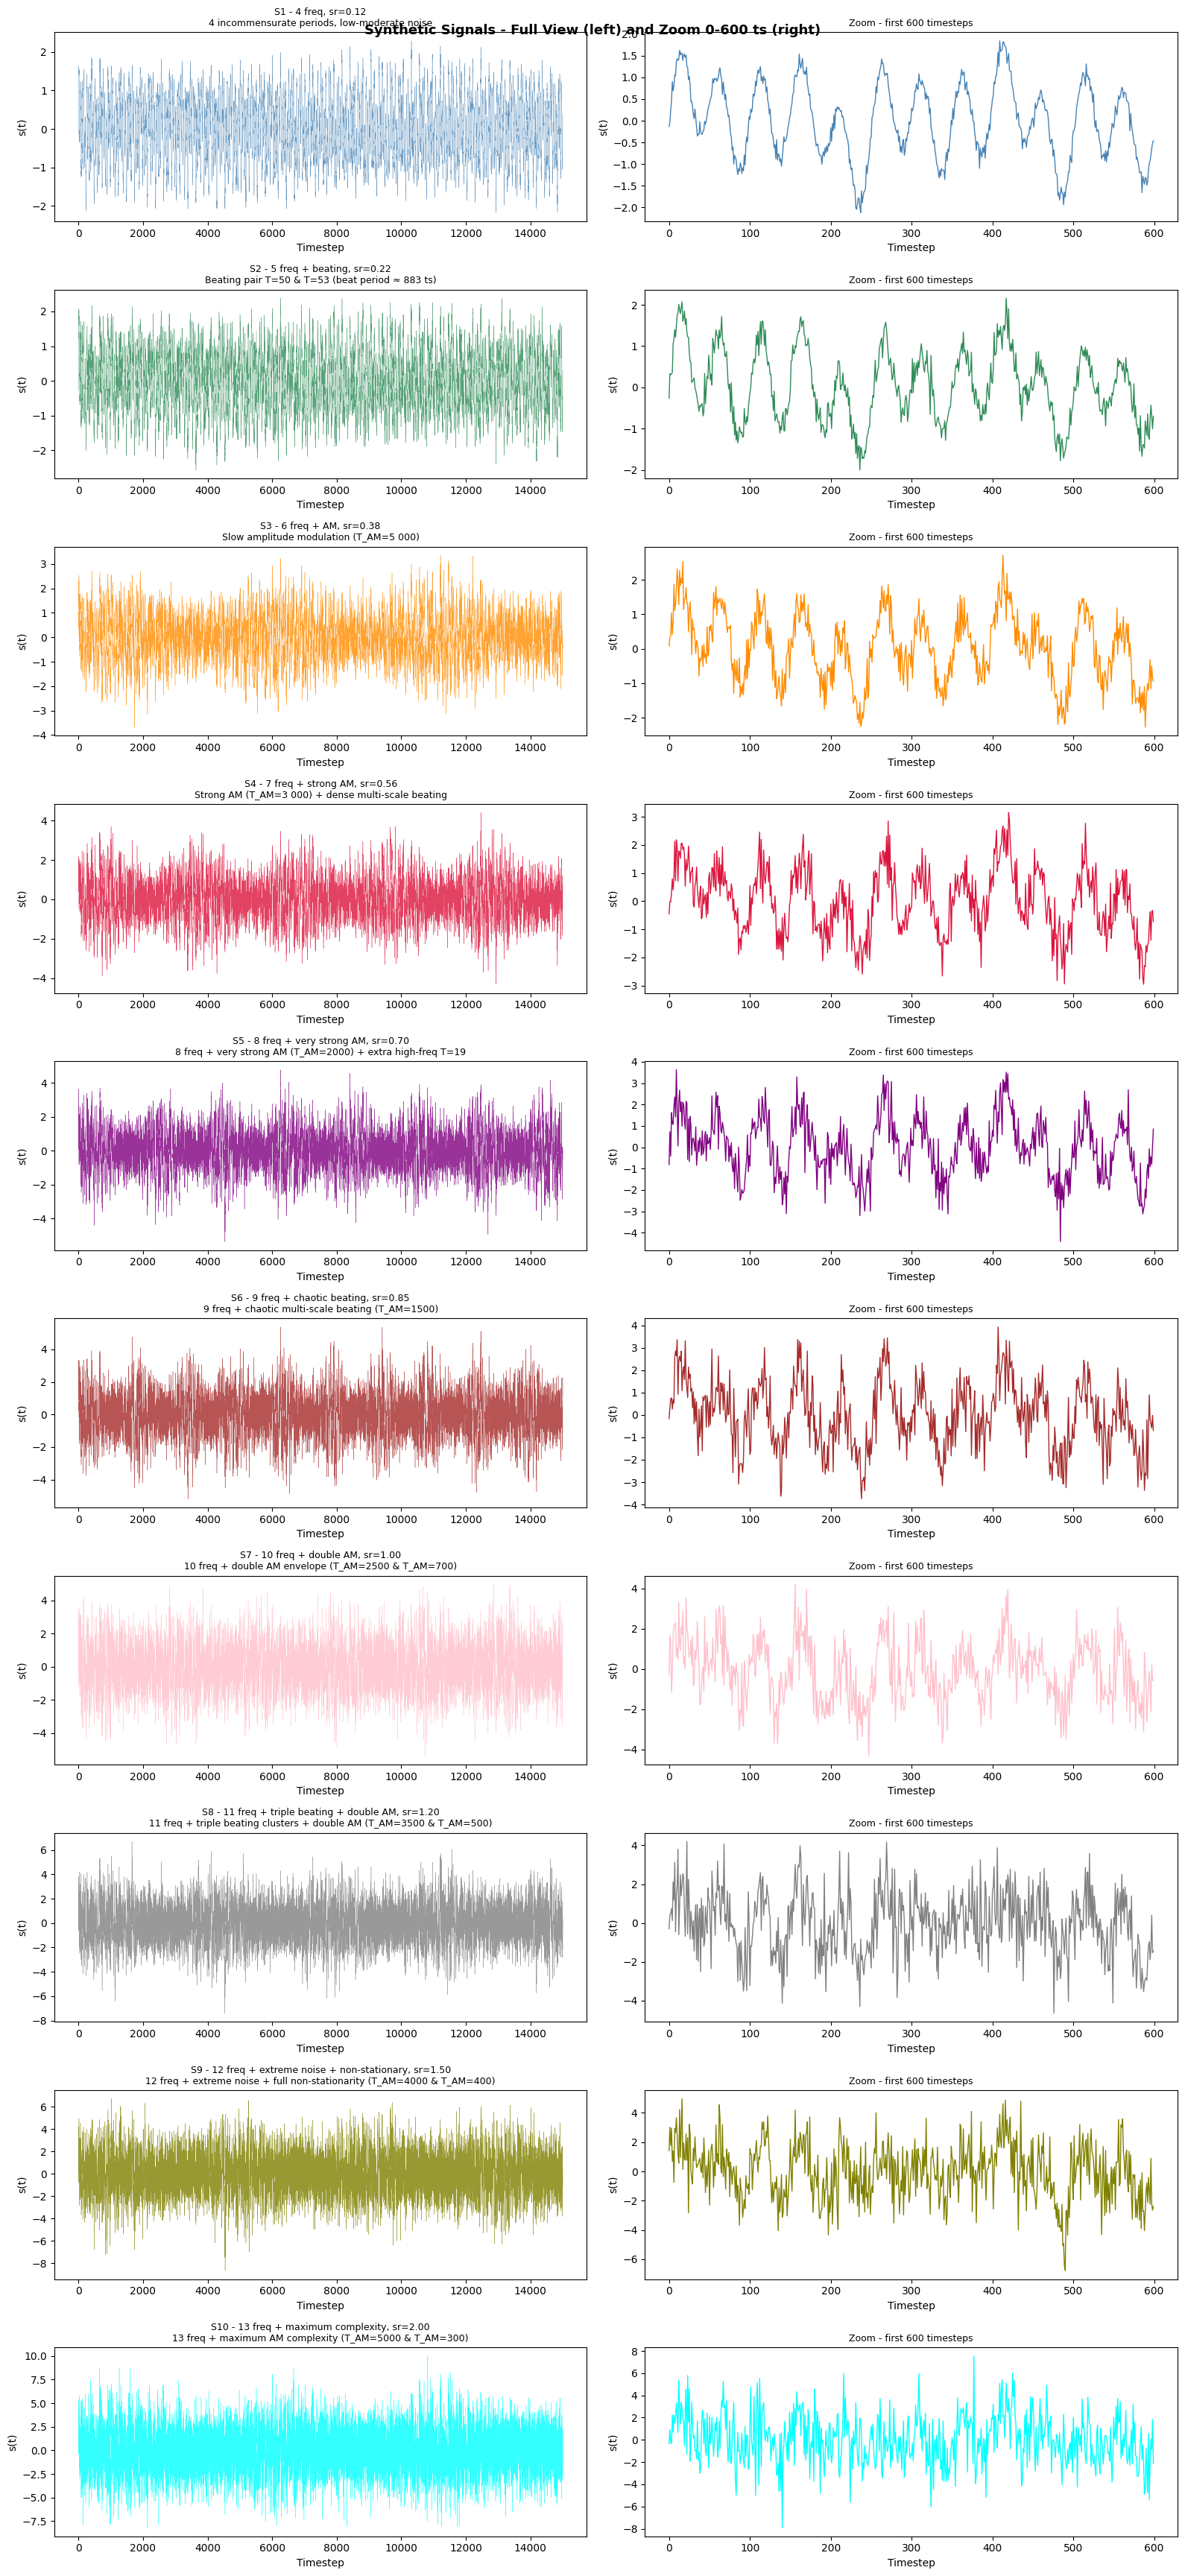

Figure saved → single_hp_outputs_3/signals_overview.png


In [4]:
# ---------------------------------------------------------------------------
# Visualise all signals - full view + zoom
# ---------------------------------------------------------------------------
n_signals = len(SIGNALS)
fig, axes = plt.subplots(n_signals, 2, figsize=(16, 3.5 * n_signals))
fig.suptitle("Synthetic Signals - Full View (left) and Zoom 0-600 ts (right)",
             fontsize=13, fontweight="bold")

colors = ["steelblue", "seagreen", "darkorange", "crimson",
          "purple", "brown", "pink", "gray", "olive", "cyan"]
for row, (name, cfg) in enumerate(SIGNALS.items()):
    sig   = cfg["data"]
    color = colors[row % len(colors)]
    label = cfg["label"]

    # Full signal
    ax = axes[row, 0]
    ax.plot(t_axis, sig, lw=0.3, color=color, alpha=0.8)
    ax.set_title(f"{label}\n{cfg['desc']}", fontsize=9)
    ax.set_xlabel("Timestep"); ax.set_ylabel("s(t)")

    # Zoom
    ax = axes[row, 1]
    ax.plot(t_axis[:600], sig[:600], lw=1.0, color=color)
    ax.set_title(f"Zoom - first 600 timesteps", fontsize=9)
    ax.set_xlabel("Timestep"); ax.set_ylabel("s(t)")

plt.tight_layout()
plt.savefig("single_hp_outputs_3/signals_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved → single_hp_outputs_3/signals_overview.png")

## 3. ESN Configuration & Helper Functions

To balance coverage and computation time, the parameter grids are slightly coarser than in
Notebooks 1 and 2 but still span the full range of interest for each architecture:

| Architecture | Parameter | Values |
|-------------|-----------|--------|
| ER | p (edge probability) | [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0] |
| WS | k (mean degree) | [2, 4, 8, 16, 32, 64] - p_rewire=0.3 fixed |
| WS | p_rewire | [0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.8, 1.0] - k=10 fixed |
| BA | m (edges per new node) | [1, 2, 5, 10, 20, 50] |

### 3.1 Helper Functions

- `build_dataset(signal, lag)` - builds the lag-input supervised dataset
- `make_reservoir_matrix(N, topology, topo_params)` - constructs W with clip-only SR control
- `run_topology_shs(...)` - temporal CV sweep over one topology parameter
- `best_setting(df, param_name)` - returns the parameter value with lowest mean RMSE
- `plot_single_hp(...)` - 3-panel single hyperparameter study plot (RMSE dist · mean RMSE bar · R² dist)
- `run_signal_study(...)` - orchestrates the full 3-architecture sweep for one signal
- `plot_esn_prediction(...)` - trains on 75% / tests on 25%, returns predictions + metrics

In [5]:
# ===========================================================================
# Helper functions
# ===========================================================================

def build_dataset(signal, lag=LAG):
    """Build supervised lag-input dataset from a 1-D time series."""
    T_sig = len(signal)
    X = np.column_stack([signal[i : T_sig - lag + i] for i in range(lag)])
    y = signal[lag:].reshape(-1, 1)
    return X, y


def make_reservoir_matrix(N, topology, topo_params, clip_sr=1.1):
    """
    Build reservoir weight matrix W with clip-only spectral radius control.
    W is rescaled only if ρ(W) > clip_sr, preserving natural SR differences
    between topologies (same philosophy as Notebook 1 Phase-B).
    Returns (W, info_dict).
    """
    rng = np.random.RandomState()
    if topology == "random":
        G = nx.erdos_renyi_graph(N, topo_params["p"], directed=True)
    elif topology == "small_world":
        k = int(topo_params["k"])
        if k % 2 != 0:
            k += 1
        k = min(max(k, 2), N - 1)
        G = nx.watts_strogatz_graph(N, k, p=topo_params["p_rewire"]).to_directed()
    elif topology == "scale_free":
        G = nx.barabasi_albert_graph(N, max(1, int(topo_params["m"]))).to_directed()
    else:
        raise ValueError(f"Unknown topology: {topology}")

    A    = nx.adjacency_matrix(G).toarray().astype(np.float64)
    mask = A > 0
    W    = np.zeros_like(A)
    W[mask] = rng.randn(mask.sum())

    eigs       = np.linalg.eigvals(W)
    sr_natural = float(np.max(np.abs(eigs))) if mask.any() else 0.0
    clipped    = sr_natural > clip_sr
    sr_actual  = clip_sr if clipped else sr_natural
    if clipped:
        W *= clip_sr / sr_natural

    info = {
        "topology":                topology,
        "N":                       N,
        "actual_density":          mask.sum() / (N * N),
        "avg_degree":              mask.sum(axis=1).mean(),
        "spectral_radius_natural": sr_natural,
        "spectral_radius_actual":  sr_actual,
        "n_edges":                 int(mask.sum()),
        "clipped":                 clipped,
    }
    return W, info


def run_hp_search(signal_data, hp_configs, n_splits=N_SPLITS, topo_p=0.3):
    """
    Random hyperparameter search for ESN (N, sr, lr, ridge, washout) on a signal.
    Uses a fixed Erdős-Rényi topology (p=topo_p) as a neutral baseline so that
    differences reflect ESN capacity, not topology choice.
    Returns the config dict with the lowest mean CV RMSE (adds 'mean_rmse' key).
    """
    tscv    = TimeSeriesSplit(n_splits=n_splits)
    X, y    = build_dataset(signal_data, lag=LAG)
    records = []

    for cfg_idx, cfg in enumerate(hp_configs):
        N, sr, lr, ridge, washout = (
            int(cfg["N"]), cfg["sr"], cfg["lr"], cfg["ridge"], int(cfg["washout"])
        )
        fold_rmses = []
        for train_idx, test_idx in tscv.split(X):
            X_tr_f, y_tr_f = X[train_idx], y[train_idx]
            X_te_f, y_te_f = X[test_idx],  y[test_idx]
            scaler = StandardScaler()
            X_tr   = scaler.fit_transform(X_tr_f)
            X_te   = scaler.transform(X_te_f)
            try:
                W, _ = make_reservoir_matrix(N, "random", {"p": topo_p}, clip_sr=sr)
                reservoir = Reservoir(units=N, W=W, lr=lr)
                model     = reservoir >> Ridge(ridge=ridge)
                model.fit(X_tr, y_tr_f, warmup=washout)
                y_pred = np.array(model.run(X_te)).reshape(-1)
                fold_rmses.append(np.sqrt(mean_squared_error(y_te_f.ravel(), y_pred)))
            except Exception:
                fold_rmses.append(np.nan)

        mean_rmse = float(np.nanmean(fold_rmses)) if fold_rmses else np.nan
        records.append({**cfg, "mean_rmse": mean_rmse})

        if (cfg_idx + 1) % 20 == 0 or cfg_idx == 0:
            valid = [r["mean_rmse"] for r in records if not np.isnan(r["mean_rmse"])]
            best_so_far = min(valid) if valid else float("nan")
            print(f"    [{cfg_idx+1:3d}/{len(hp_configs)}]  best RMSE so far: {best_so_far:.5f}")

    df      = pd.DataFrame(records).dropna(subset=["mean_rmse"])
    best    = df.loc[df["mean_rmse"].idxmin()].to_dict()
    return best


def run_topology_shs(topology, param_name, param_values, esn_params,
                     fixed_topo=None, n_splits=N_SPLITS):
    """
    Single Hyperparameter Study over one structural topology parameter.
    Uses temporal cross-validation with n_splits folds.
    Returns a DataFrame with columns [param_name, 'fold', 'rmse', 'mae', 'r2',
    'density', 'sr_natural', 'train_time_s'].
    """
    tscv    = TimeSeriesSplit(n_splits=n_splits)
    fixed   = fixed_topo or {}
    records = []
    print(f"    [{topology}] sweep '{param_name}': "
          f"{len(param_values)} values x {n_splits} folds "
          f"= {len(param_values)*n_splits} evals")

    for val in param_values:
        topo_params = {**fixed, param_name: val}
        try:
            W, info = make_reservoir_matrix(esn_params["N"], topology, topo_params)
        except Exception as exc:
            print(f"      [MATRIX ERROR] {param_name}={val}: {exc}")
            for fi in range(n_splits):
                records.append({param_name: val, "fold": fi, "rmse": np.nan,
                                "mae": np.nan, "r2": np.nan, "density": np.nan,
                                "sr_natural": np.nan, "train_time_s": np.nan})
            continue

        if info["clipped"]:
            print(f"      [CLIP] {param_name}={val}: "
                  f"sr_nat={info['spectral_radius_natural']:.3f} "
                  f"→ {info['spectral_radius_actual']:.3f}")

        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
            X_tr_f, y_tr_f = X_all[train_idx], y_all[train_idx]
            X_te_f, y_te_f = X_all[test_idx],  y_all[test_idx]

            scaler = StandardScaler()
            X_tr   = scaler.fit_transform(X_tr_f)
            X_te   = scaler.transform(X_te_f)

            try:
                t0        = time.time()
                reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                model     = reservoir >> Ridge(ridge=esn_params["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                y_pred    = np.array(model.run(X_te)).reshape(-1)
                y_true    = y_te_f.ravel()
                records.append({
                    param_name:     val,
                    "fold":         fold_idx,
                    "rmse":         np.sqrt(mean_squared_error(y_true, y_pred)),
                    "mae":          mean_absolute_error(y_true, y_pred),
                    "r2":           r2_score(y_true, y_pred),
                    "density":      info["actual_density"],
                    "sr_natural":   info["spectral_radius_natural"],
                    "train_time_s": time.time() - t0,
                })
            except Exception as exc:
                print(f"      [ERROR] {param_name}={val}, fold {fold_idx}: {exc}")
                records.append({param_name: val, "fold": fold_idx,
                                "rmse": np.nan, "mae": np.nan, "r2": np.nan,
                                "density": np.nan, "sr_natural": np.nan,
                                "train_time_s": np.nan})

    return pd.DataFrame(records)


def best_setting(df, param_name):
    """Return the parameter value with the lowest mean RMSE across folds."""
    agg = df.dropna(subset=["rmse"]).groupby(param_name)["rmse"].mean()
    return agg.idxmin()


def plot_single_hp(df, hp_name, hp_values, label_map=None, title="",
            palette="colorblind", save_path=None):
    """
    3-panel Single Hyperparameter Study Plot:
      Panel 1 - RMSE fold distribution (box + strip)
      Panel 2 - Mean RMSE ± std (bar chart)
      Panel 3 - R² fold distribution (box + strip)
    """
    labels  = [label_map[v] if label_map else str(v) for v in hp_values]
    df_plt  = df.dropna(subset=["rmse"]).copy()
    lbl_map = dict(zip(hp_values, labels))
    df_plt["_lbl"] = df_plt[hp_name].map(lbl_map)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    if title:
        fig.suptitle(title, fontsize=11, fontweight="bold", y=1.01)

    # Panel 1 - RMSE distribution
    ax = axes[0]
    sns.boxplot(data=df_plt, x="_lbl", y="rmse", order=labels,
                palette=palette, width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_plt, x="_lbl", y="rmse", order=labels,
                  color="black", size=4, alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel(hp_name); ax.set_ylabel("RMSE")
    ax.set_title("RMSE - fold distribution")
    ax.tick_params(axis="x", rotation=45)

    # Panel 2 - Mean RMSE ± std
    ax = axes[1]
    summ = (df_plt.groupby("_lbl")["rmse"]
              .agg(["mean", "std"])
              .reindex(labels).reset_index())
    ax.errorbar(summ["_lbl"], summ["mean"], yerr=summ["std"],
                marker="o", capsize=6, linewidth=2, markersize=8,
                color="steelblue", elinewidth=1.5)
    ax.set_xlabel(hp_name); ax.set_ylabel("Mean RMSE ± std")
    ax.set_title("Mean RMSE ± std across folds")
    ax.tick_params(axis="x", rotation=45)

    # Panel 3 - R² distribution
    ax = axes[2]
    sns.boxplot(data=df_plt, x="_lbl", y="r2", order=labels,
                palette=palette, width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_plt, x="_lbl", y="r2", order=labels,
                  color="black", size=4, alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel(hp_name); ax.set_ylabel("R²")
    ax.set_title("R² - fold distribution")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"    Figure saved → {save_path}")
    plt.show()


def plot_esn_prediction(sig_name, sig_cfg, esn_params, topo, topo_params,
                        test_frac=0.25, zoom=400, ax_row=None):
    """
    Train on first (1-test_frac) of signal, predict on remainder.
    If ax_row is provided (list of 2 axes), draw into them; else create a new figure.
    Returns (y_true, y_pred, rmse, r2).
    """
    signal   = sig_cfg["data"]
    X_all, y_all = build_dataset(signal, lag=LAG)
    n        = len(X_all)
    n_train  = int(n * (1 - test_frac))

    X_train, y_train = X_all[:n_train], y_all[:n_train]
    X_test,  y_test  = X_all[n_train:], y_all[n_train:]

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_train)
    X_te   = scaler.transform(X_test)

    W, info = make_reservoir_matrix(esn_params["N"], topo, topo_params)
    reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
    model     = reservoir >> Ridge(ridge=esn_params["ridge"])
    model.fit(X_tr, y_train, warmup=int(esn_params["washout"]))
    y_pred = np.array(model.run(X_te)).reshape(-1)
    y_true = y_test.ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    t_all  = np.arange(len(signal))
    t_test = t_all[LAG + n_train:]

    own_fig = ax_row is None
    if own_fig:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    else:
        axes = ax_row

    # Full view
    ax = axes[0]
    ax.plot(t_all[:LAG+n_train], signal[:LAG+n_train],
            lw=0.25, color="lightgray", label="Training signal")
    ax.plot(t_test, y_true,  lw=0.8, color="steelblue",  label="Real (test)")
    ax.plot(t_test, y_pred,  lw=0.8, color="tomato", alpha=0.85, label="Predicted")
    ax.axvline(LAG + n_train, color="black", ls="--", lw=0.8)
    ax.set_title(f"{sig_name}   RMSE={rmse:.4f}   R²={r2:.4f}", fontsize=9)
    ax.set_xlabel("Timestep"); ax.set_ylabel("s(t)")
    ax.legend(loc="upper left", fontsize=7)

    # Zoom
    ax = axes[1]
    ax.plot(t_test[:zoom], y_true[:zoom], lw=1.2, color="steelblue", label="Real")
    ax.plot(t_test[:zoom], y_pred[:zoom], lw=1.2, color="tomato", ls="--", label="Predicted")
    ax.set_title(f"Zoom - first {zoom} test timesteps", fontsize=9)
    ax.set_xlabel("Timestep"); ax.set_ylabel("s(t)")
    ax.legend(fontsize=7)

    if own_fig:
        plt.tight_layout()
        plt.show()

    return y_true, y_pred, rmse, r2


def run_signal_study(sig_name, sig_cfg, esn_params,
                     er_p_values, ws_k_values, ws_prw_values, ba_m_values,
                     fixed_k=4, fixed_p_rewire=0.1,
                     output_dir="single_hp_outputs_3"):
    """
    Full 3-architecture topology SHS study for one signal.
    Returns a result dict containing DataFrames and best-param / best-RMSE values.
    """
    global X_all, y_all
    signal = sig_cfg["data"]
    X_all, y_all = build_dataset(signal, lag=LAG)

    print(f"\n{'='*62}")
    print(f"  {sig_cfg['label']}")
    print(f"  {sig_cfg['desc']}")
    print(f"  Dataset: X={X_all.shape}  y={y_all.shape}")
    print(f"{'='*62}")
    t_start = time.time()

    # --- Erdős-Rényi: sweep p ---
    print("\n[ER] Sweeping connection probability p ...")
    df_er = run_topology_shs("random", "p", er_p_values, esn_params)
    df_er.to_csv(f"{output_dir}/shs_{sig_name}_er_p.csv", index=False)
    plot_single_hp(df_er, "p", er_p_values,
             title=f"[{sig_name}] ER - Single Hyperparameter Study on p",
             save_path=f"{output_dir}/shs_{sig_name}_er_p.png")

    # --- Watts-Strogatz: sweep k (p_rewire fixed) ---
    print(f"\n[WS] Sweeping mean degree k (p_rewire={fixed_p_rewire} fixed) ...")
    df_ws_k = run_topology_shs("small_world", "k", ws_k_values, esn_params,
                               fixed_topo={"p_rewire": fixed_p_rewire})
    df_ws_k.to_csv(f"{output_dir}/shs_{sig_name}_ws_k.csv", index=False)
    plot_single_hp(df_ws_k, "k", ws_k_values,
             title=f"[{sig_name}] WS - Single Hyperparameter Study on k (p_rewire={fixed_p_rewire} fixed)",
             save_path=f"{output_dir}/shs_{sig_name}_ws_k.png")

    # --- Watts-Strogatz: sweep p_rewire (k fixed) ---
    print(f"\n[WS] Sweeping rewiring prob p_rewire (k={fixed_k} fixed) ...")
    df_ws_prw = run_topology_shs("small_world", "p_rewire", ws_prw_values, esn_params,
                                 fixed_topo={"k": fixed_k})
    df_ws_prw.to_csv(f"{output_dir}/shs_{sig_name}_ws_prw.csv", index=False)
    ws_prw_labels = {v: str(v) for v in ws_prw_values}
    plot_single_hp(df_ws_prw, "p_rewire", ws_prw_values, label_map=ws_prw_labels,
             title=f"[{sig_name}] WS - Single Hyperparameter Study on p_rewire (k={fixed_k} fixed)",
             save_path=f"{output_dir}/shs_{sig_name}_ws_prw.png")

    # --- Barabási-Albert: sweep m ---
    print("\n[BA] Sweeping edges-per-new-node m ...")
    df_ba = run_topology_shs("scale_free", "m", ba_m_values, esn_params)
    ba_labels = {v: str(v) for v in ba_m_values}
    df_ba.to_csv(f"{output_dir}/shs_{sig_name}_ba_m.csv", index=False)
    plot_single_hp(df_ba, "m", ba_m_values, label_map=ba_labels,
             title=f"[{sig_name}] BA - Single Hyperparameter Study on m",
             save_path=f"{output_dir}/shs_{sig_name}_ba_m.png")

    # --- Extract best params & best RMSE ---
    best_er_p   = best_setting(df_er,    "p")
    best_ws_k   = best_setting(df_ws_k,  "k")
    best_ws_prw = best_setting(df_ws_prw, "p_rewire")
    best_ba_m   = best_setting(df_ba,    "m")

    rmse_er      = df_er[df_er["p"]          == best_er_p  ]["rmse"].mean()
    rmse_ws_k    = df_ws_k[df_ws_k["k"]     == best_ws_k  ]["rmse"].mean()
    rmse_ws_prw  = df_ws_prw[df_ws_prw["p_rewire"] == best_ws_prw]["rmse"].mean()
    rmse_ba      = df_ba[df_ba["m"]          == best_ba_m  ]["rmse"].mean()
    rmse_ws_best = min(rmse_ws_k, rmse_ws_prw)

    elapsed = time.time() - t_start
    print(f"\n{'─'*62}")
    print(f"  Best ER  : p={best_er_p}          → mean RMSE = {rmse_er:.5f}")
    print(f"  Best WS  : k={best_ws_k}, p_rewire={best_ws_prw}")
    print(f"              RMSE(k)={rmse_ws_k:.5f}  RMSE(prw)={rmse_ws_prw:.5f}  best={rmse_ws_best:.5f}")
    print(f"  Best BA  : m={best_ba_m}          → mean RMSE = {rmse_ba:.5f}")
    print(f"  Elapsed  : {elapsed/60:.1f} min")

    return {
        "label":         sig_cfg["label"],
        "n_components":  sig_cfg["n_components"],
        "noise_std":     sig_cfg["noise_std"],
        "extra":         sig_cfg["extra"],
        "ER":   {"df": df_er,     "best_p":   best_er_p,   "best_rmse": rmse_er},
        "WS_k": {"df": df_ws_k,   "best_k":   best_ws_k,   "best_rmse": rmse_ws_k},
        "WS_p": {"df": df_ws_prw, "best_prw": best_ws_prw, "best_rmse": rmse_ws_prw},
        "BA":   {"df": df_ba,     "best_m":   best_ba_m,   "best_rmse": rmse_ba},
        "WS_best_rmse": rmse_ws_best,
    }


print("All helper functions defined.")

All helper functions defined.


In [6]:
# Container for all study results - populated as we run each signal below
study_results = {}

### 3.2 Per-Signal ESN Hyperparameter Search

Before studying topology effects, we tune ESN hyperparameters **(N, sr, lr, ridge, washout)**
independently for each signal via a **random search with 5-fold temporal CV**, using a neutral
Erdős-Rényi baseline topology (p=0.3) so that any RMSE differences reflect capacity, not structure.

The resulting `BEST_PARAMS_PER_SIGNAL` dict is then passed to each signal's topology study,
ensuring that topology comparisons are always made at each signal's optimal operating point.

In [ ]:
import itertools
import random as _random

# ---------------------------------------------------------------------------
# Hyperparameter search grid
# ---------------------------------------------------------------------------
HP_GRID = {
    "N":       [20, 30, 50, 100, 200],
    "sr":      [0.5, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5],
    "lr":      [0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
    "ridge":   [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    "washout": [5, 10, 20, 50],
}
N_HP_CONFIGS = 100   # random configs sampled from the full Cartesian product

_random.seed(42)
np.random.seed(42)
_all_combos = list(itertools.product(*HP_GRID.values()))
_sampled    = _random.sample(_all_combos, min(N_HP_CONFIGS, len(_all_combos)))
HP_CONFIGS  = [dict(zip(HP_GRID.keys(), c)) for c in _sampled]

print(f"HP random search: {len(HP_CONFIGS)} configs x {N_SPLITS} folds x 4 signals "
      f"= {len(HP_CONFIGS) * N_SPLITS * 4} total evals\n")

# ---------------------------------------------------------------------------
# Run per-signal search
# ---------------------------------------------------------------------------
BEST_PARAMS_PER_SIGNAL = {}
_hp_best_rmse          = {}   # store CV RMSE for summary

for sig_name in ["S1", "S2", "S3", "S4"]:
    print(f"\n{'='*55}")
    print(f"  HP search for {sig_name}: {SIGNALS[sig_name]['label']}")
    print(f"{'='*55}")
    best = run_hp_search(SIGNALS[sig_name]["data"], HP_CONFIGS)
    BEST_PARAMS_PER_SIGNAL[sig_name] = {
        "N":       int(best["N"]),
        "sr":      best["sr"],
        "lr":      best["lr"],
        "ridge":   best["ridge"],
        "washout": int(best["washout"]),
    }
    _hp_best_rmse[sig_name] = best["mean_rmse"]
    print(f"  → Best: {BEST_PARAMS_PER_SIGNAL[sig_name]}  (CV RMSE={best['mean_rmse']:.5f})")

# ---------------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------------
print(f"\n{'='*73}")
print(f"  {'Signal':<8} {'N':>5} {'sr':>6} {'lr':>6} {'ridge':>8} {'washout':>8}  {'CV RMSE':>9}")
print(f"  {'─'*67}")
for sig_name in ["S1", "S2", "S3", "S4"]:
    p = BEST_PARAMS_PER_SIGNAL[sig_name]
    print(f"  {sig_name:<8} {p['N']:>5} {p['sr']:>6.2f} {p['lr']:>6.3f} "
          f"{p['ridge']:>8.0e} {p['washout']:>8}  {_hp_best_rmse[sig_name]:>9.5f}")
print(f"{'='*73}")

HP random search: 100 configs × 10 folds × 4 signals = 4000 total evals


  HP search for S1: S1 - 4 freq, sr=0.12
    [  1/100]  best RMSE so far: 0.15013
    [ 20/100]  best RMSE so far: 0.13824
    [ 40/100]  best RMSE so far: 0.13824
    [ 60/100]  best RMSE so far: 0.13824
    [ 80/100]  best RMSE so far: 0.13824
    [100/100]  best RMSE so far: 0.13824
  → Best: {'N': 200, 'sr': 0.9, 'lr': 0.2, 'ridge': 0.1, 'washout': 50}  (CV RMSE=0.13824)

  HP search for S2: S2 - 5 freq + beating, sr=0.22
    [  1/100]  best RMSE so far: 0.26323
    [ 20/100]  best RMSE so far: 0.25115
    [ 40/100]  best RMSE so far: 0.25115
    [ 60/100]  best RMSE so far: 0.25115
    [ 80/100]  best RMSE so far: 0.25115
    [100/100]  best RMSE so far: 0.24956
  → Best: {'N': 200, 'sr': 1.0, 'lr': 0.05, 'ridge': 0.1, 'washout': 20}  (CV RMSE=0.24956)

  HP search for S3: S3 - 6 freq + AM, sr=0.38
    [  1/100]  best RMSE so far: 0.43492
    [ 20/100]  best RMSE so far: 0.42702
    [ 40/100]  best RMSE so f

### 3.3 Preliminary CV — Canonical Best Topology Parameters

Using each signal's individually tuned ESN hyperparameters, we sweep the key topology parameters
on **Signal S1** (the simplest signal) to identify canonical starting ranges. These are used
as reference values in the final comparison grid (Section 10).

In [ ]:
# ---------------------------------------------------------------------------
# Preliminary Cross-Validation on S1 (uses S1-specific best HP)
# ---------------------------------------------------------------------------
BEST_PARAMS = BEST_PARAMS_PER_SIGNAL["S1"]   # S1-tuned baseline for topology sweep

N = BEST_PARAMS["N"]   # shorthand for valid-range filters below

ER_P_VALUES   = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

WS_K_VALUES   = [v for v in [0, 2, 3, 4, 8, 16, 32, 64, N//2, N-1] if v < N]
WS_PRW_VALUES = [0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
FIXED_K       = min(10, N - 1)   # held fixed while sweeping p_rewire
FIXED_P_REWIRE = 0.3             # held fixed while sweeping k

BA_M_VALUES   = []
m_val = 1
while m_val < N:
    BA_M_VALUES.append(m_val)
    m_val *= 2



X_all, y_all = build_dataset(SIGNALS["S1"]["data"], lag=LAG)

print("=" * 62)
print("  Preliminary CV on S1 — canonical topology param search")
print(f"  {N_SPLITS}-fold temporal CV, reservoir N={BEST_PARAMS['N']}")
print(f"  ESN params: sr={BEST_PARAMS['sr']}  lr={BEST_PARAMS['lr']}")
print(f"              ridge={BEST_PARAMS['ridge']}  washout={BEST_PARAMS['washout']}")
print("=" * 62)

# ── ER: sweep connection probability p ─────────────────────────────────────
print("\n[ER] Sweeping p …")
df_shs_er      = run_topology_shs("random", "p", ER_P_VALUES, BEST_PARAMS)
CANONICAL_ER_P = best_setting(df_shs_er, "p")

# ── WS: sweep mean degree k (p_rewire fixed) ───────────────────────────────
print(f"\n[WS] Sweeping k  (p_rewire={FIXED_P_REWIRE} fixed) …")
df_shs_ws_k    = run_topology_shs("small_world", "k", WS_K_VALUES, BEST_PARAMS,
                                  fixed_topo={"p_rewire": FIXED_P_REWIRE})
CANONICAL_WS_K = best_setting(df_shs_ws_k, "k")

# ── WS: sweep rewiring probability p_rewire (k fixed) ─────────────────────
print(f"\n[WS] Sweeping p_rewire  (k={FIXED_K} fixed) …")
df_shs_ws_prw    = run_topology_shs("small_world", "p_rewire", WS_PRW_VALUES, BEST_PARAMS,
                                    fixed_topo={"k": FIXED_K})
CANONICAL_WS_PRW = best_setting(df_shs_ws_prw, "p_rewire")

# ── BA: sweep edges-per-new-node m ─────────────────────────────────────────
print("\n[BA] Sweeping m …")
df_shs_ba       = run_topology_shs("scale_free", "m", BA_M_VALUES, BEST_PARAMS)
CANONICAL_BA_M  = best_setting(df_shs_ba, "m")

# ── Summary ────────────────────────────────────────────────────────────────
print(f"\n{'─'*62}")
print("  Canonical best topology parameters  (used in Section 10):")
print(f"    ER  : p        = {CANONICAL_ER_P}")
print(f"    WS  : k        = {CANONICAL_WS_K}")
print(f"    WS  : p_rewire = {CANONICAL_WS_PRW}")
print(f"    BA  : m        = {CANONICAL_BA_M}")
print(f"{'─'*62}")

  Preliminary CV on S1 — canonical topology param search
  10-fold temporal CV, reservoir N=200
  ESN params: sr=0.9  lr=0.2
              ridge=0.1  washout=50

[ER] Sweeping p …
    [random] sweep 'p': 11 values x 10 folds = 110 evals
      [CLIP] p=0.01: sr_nat=1.329 → 1.100
      [CLIP] p=0.02: sr_nat=2.259 → 1.100
      [CLIP] p=0.05: sr_nat=3.238 → 1.100
      [CLIP] p=0.1: sr_nat=4.540 → 1.100
      [CLIP] p=0.2: sr_nat=6.484 → 1.100
      [CLIP] p=0.3: sr_nat=8.175 → 1.100
      [CLIP] p=0.5: sr_nat=10.176 → 1.100
      [CLIP] p=1.0: sr_nat=14.545 → 1.100

[WS] Sweeping k  (p_rewire=0.3 fixed) …
    [small_world] sweep 'k': 9 values x 10 folds = 90 evals
      [CLIP] k=2: sr_nat=2.101 → 1.100
      [CLIP] k=3: sr_nat=2.925 → 1.100
      [CLIP] k=4: sr_nat=2.512 → 1.100
      [CLIP] k=8: sr_nat=3.482 → 1.100
      [CLIP] k=16: sr_nat=4.778 → 1.100
      [CLIP] k=32: sr_nat=5.825 → 1.100
      [CLIP] k=64: sr_nat=8.219 → 1.100
      [CLIP] k=100: sr_nat=10.359 → 1.100
      [CLIP

## 4. Topology Study - Signal S1
**4 incommensurate frequencies, sr=0.12** - one extra period (T=83) on top of the NB1
baseline; noise is 2.4x higher. This is the mildest step up in difficulty.

Expected behaviour: architecture differences should be small (signal is still relatively
regular), but we expect all three to track the signal well.


  S1 - 4 freq, sr=0.12
  4 incommensurate periods, low-moderate noise
  Dataset: X=(14990, 10)  y=(14990, 1)

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 11 values x 10 folds = 110 evals
      [CLIP] p=0.01: sr_nat=1.443 → 1.100
      [CLIP] p=0.02: sr_nat=2.162 → 1.100
      [CLIP] p=0.05: sr_nat=3.112 → 1.100
      [CLIP] p=0.1: sr_nat=4.465 → 1.100
      [CLIP] p=0.2: sr_nat=6.542 → 1.100
      [CLIP] p=0.3: sr_nat=7.937 → 1.100
      [CLIP] p=0.5: sr_nat=10.610 → 1.100
      [CLIP] p=1.0: sr_nat=14.661 → 1.100
    Figure saved → single_hp_outputs_3/shs_S1_er_p.png


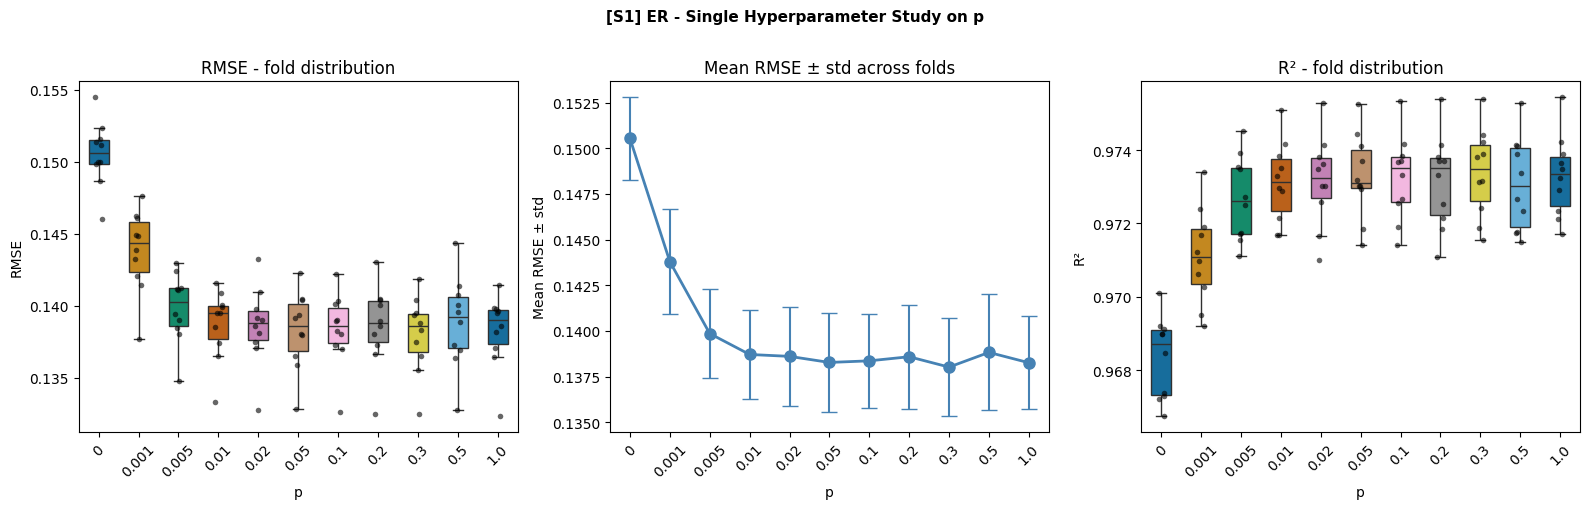


[WS] Sweeping mean degree k (p_rewire=0.1 fixed) ...
    [small_world] sweep 'k': 9 values x 10 folds = 90 evals
      [CLIP] k=2: sr_nat=2.181 → 1.100
      [CLIP] k=3: sr_nat=3.423 → 1.100
      [CLIP] k=4: sr_nat=3.705 → 1.100
      [CLIP] k=8: sr_nat=3.632 → 1.100
      [CLIP] k=16: sr_nat=4.525 → 1.100
      [CLIP] k=32: sr_nat=5.870 → 1.100
      [CLIP] k=64: sr_nat=8.461 → 1.100
      [CLIP] k=100: sr_nat=10.277 → 1.100
      [CLIP] k=199: sr_nat=14.964 → 1.100
    Figure saved → single_hp_outputs_3/shs_S1_ws_k.png


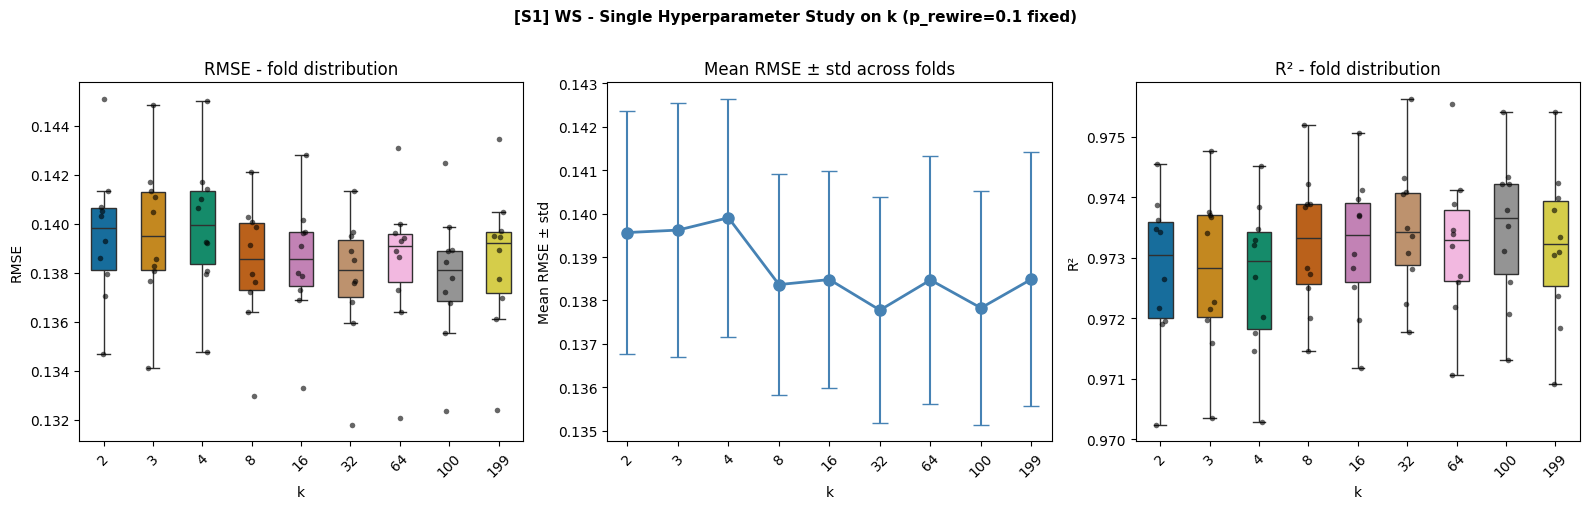


[WS] Sweeping rewiring prob p_rewire (k=4 fixed) ...
    [small_world] sweep 'p_rewire': 11 values x 10 folds = 110 evals
      [CLIP] p_rewire=0: sr_nat=2.896 → 1.100
      [CLIP] p_rewire=0.001: sr_nat=3.333 → 1.100
      [CLIP] p_rewire=0.005: sr_nat=2.905 → 1.100
      [CLIP] p_rewire=0.01: sr_nat=2.903 → 1.100
      [CLIP] p_rewire=0.02: sr_nat=2.726 → 1.100
      [CLIP] p_rewire=0.05: sr_nat=3.259 → 1.100
      [CLIP] p_rewire=0.1: sr_nat=2.817 → 1.100
      [CLIP] p_rewire=0.2: sr_nat=3.547 → 1.100
      [CLIP] p_rewire=0.3: sr_nat=3.315 → 1.100
      [CLIP] p_rewire=0.5: sr_nat=2.815 → 1.100
      [CLIP] p_rewire=1.0: sr_nat=2.798 → 1.100
    Figure saved → single_hp_outputs_3/shs_S1_ws_prw.png


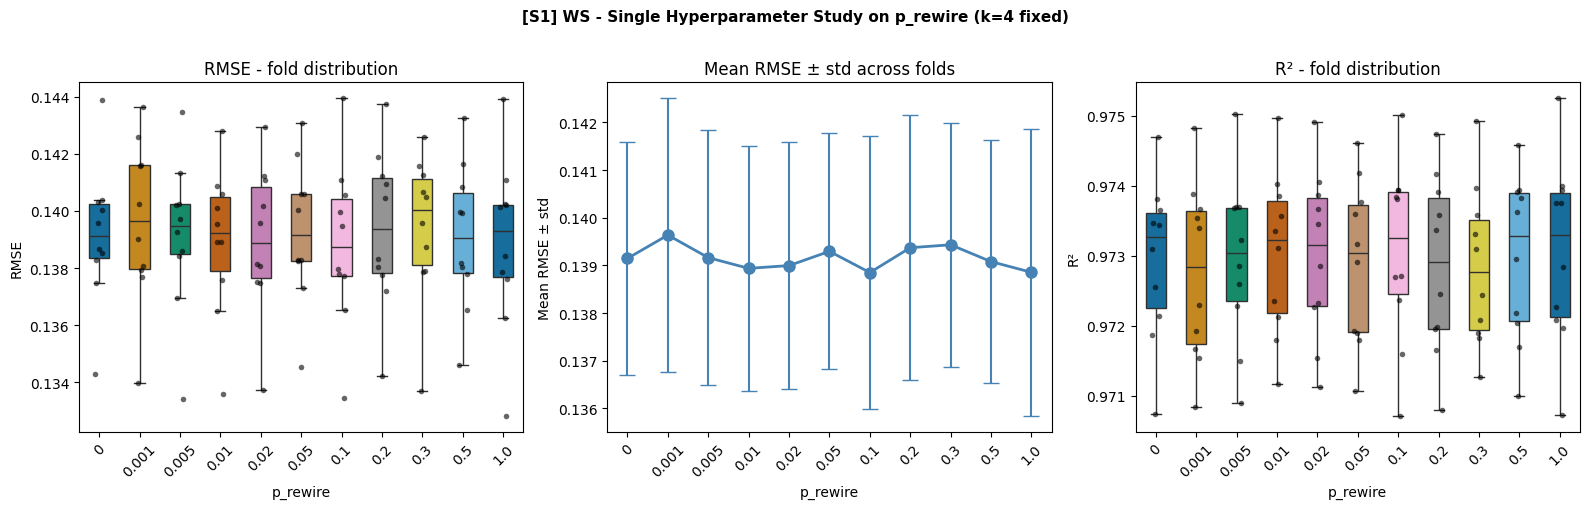


[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 11 values x 10 folds = 110 evals
      [CLIP] m=1: sr_nat=3.159 → 1.100
      [CLIP] m=2: sr_nat=3.131 → 1.100
      [CLIP] m=4: sr_nat=4.277 → 1.100
      [CLIP] m=8: sr_nat=5.410 → 1.100
      [CLIP] m=16: sr_nat=6.262 → 1.100
      [CLIP] m=32: sr_nat=8.084 → 1.100
      [CLIP] m=64: sr_nat=10.055 → 1.100
      [CLIP] m=100: sr_nat=10.973 → 1.100
      [CLIP] m=140: sr_nat=10.541 → 1.100
      [CLIP] m=180: sr_nat=8.625 → 1.100
      [CLIP] m=199: sr_nat=1.539 → 1.100
    Figure saved → single_hp_outputs_3/shs_S1_ba_m.png


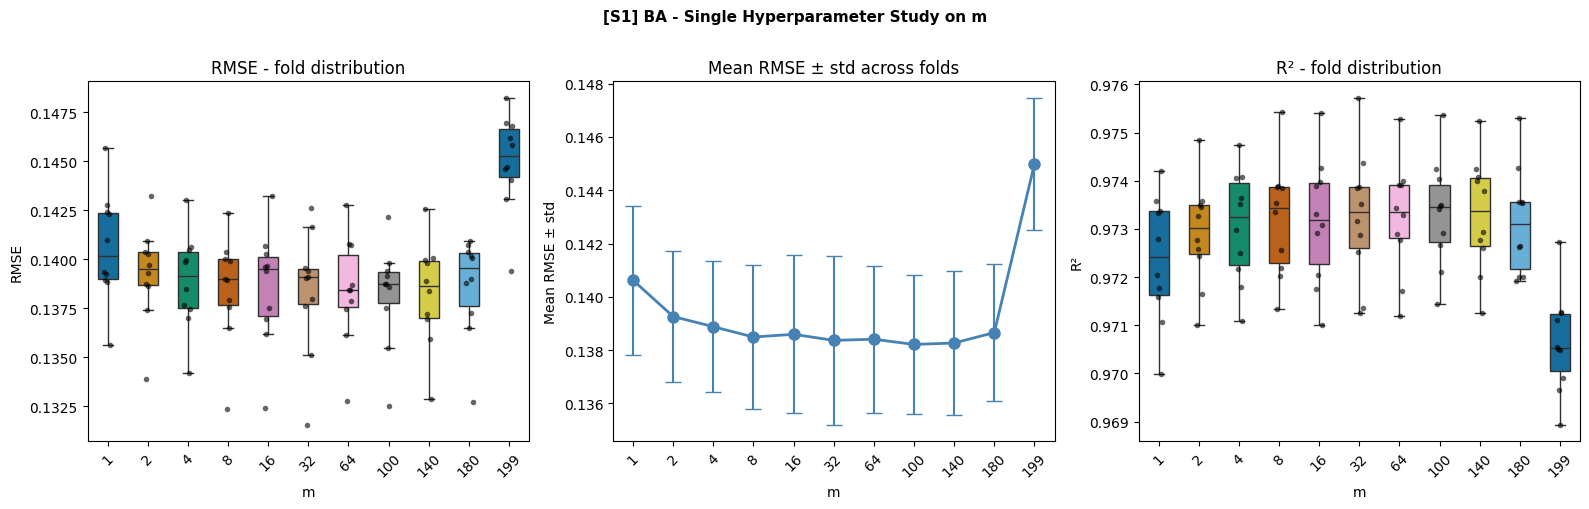


──────────────────────────────────────────────────────────────
  Best ER  : p=0.3          → mean RMSE = 0.13802
  Best WS  : k=32, p_rewire=0.1
              RMSE(k)=0.13778  RMSE(prw)=0.13885  best=0.13778
  Best BA  : m=100          → mean RMSE = 0.13821
  Elapsed  : 1.6 min


In [9]:
study_results["S1"] = run_signal_study(
    "S1", SIGNALS["S1"], BEST_PARAMS_PER_SIGNAL["S1"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
)

## 5. Topology Study - Signal S2
**5 frequencies + beating pair (T=50 & T=53), sr=0.22** - the near-harmonic pair
creates a slow amplitude modulation with beat period ≈ 883 timesteps that is fully
implicit in the signal. Detecting it requires the reservoir to hold correlations over
~900 steps, which depends heavily on the recurrent structure.

Expected behaviour: architectures with richer recurrent connectivity (BA high-m,
WS low-k) should pull ahead. ER may be more sensitive to p.


  S2 - 5 freq + beating, sr=0.22
  Beating pair T=50 & T=53 (beat period ≈ 883 ts)
  Dataset: X=(14990, 10)  y=(14990, 1)

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 11 values x 10 folds = 110 evals
      [CLIP] p=0.01: sr_nat=1.675 → 1.100
      [CLIP] p=0.02: sr_nat=2.170 → 1.100
      [CLIP] p=0.05: sr_nat=3.212 → 1.100
      [CLIP] p=0.1: sr_nat=4.737 → 1.100
      [CLIP] p=0.2: sr_nat=6.548 → 1.100
      [CLIP] p=0.3: sr_nat=7.997 → 1.100
      [CLIP] p=0.5: sr_nat=10.541 → 1.100
      [CLIP] p=1.0: sr_nat=14.503 → 1.100
    Figure saved → single_hp_outputs_3/shs_S2_er_p.png


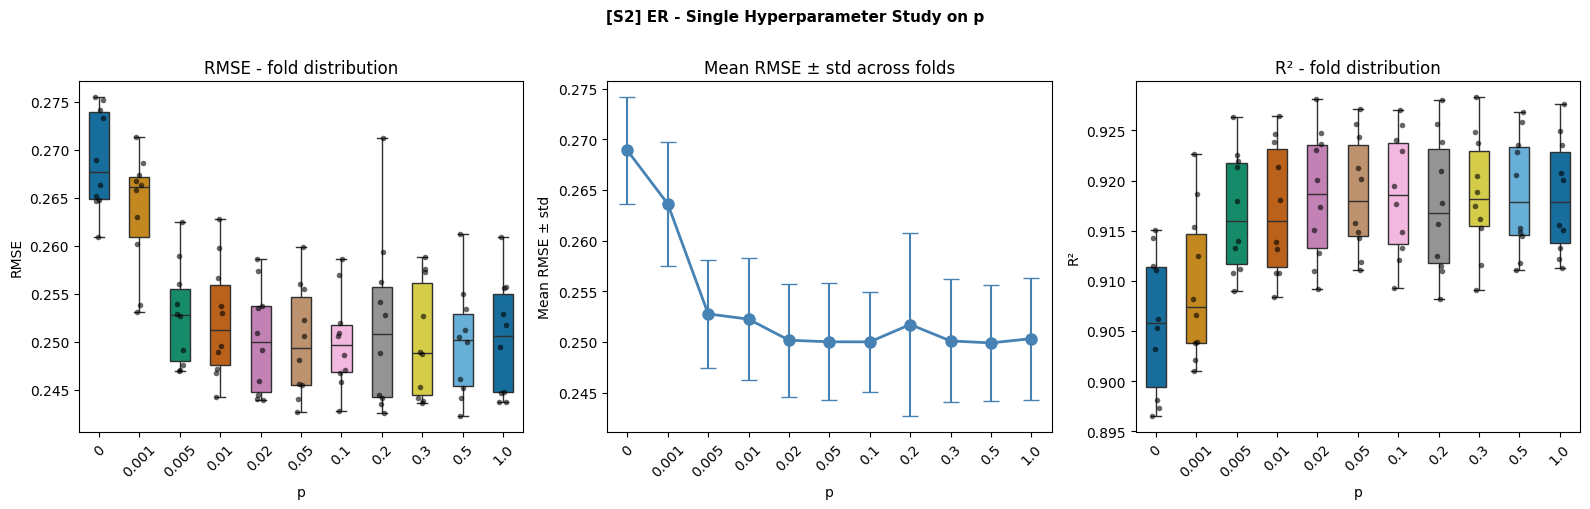


[WS] Sweeping mean degree k (p_rewire=0.1 fixed) ...
    [small_world] sweep 'k': 9 values x 10 folds = 90 evals
      [CLIP] k=2: sr_nat=2.163 → 1.100
      [CLIP] k=3: sr_nat=3.745 → 1.100
      [CLIP] k=4: sr_nat=2.886 → 1.100
      [CLIP] k=8: sr_nat=3.371 → 1.100
      [CLIP] k=16: sr_nat=4.755 → 1.100
      [CLIP] k=32: sr_nat=6.390 → 1.100
      [CLIP] k=64: sr_nat=8.507 → 1.100
      [CLIP] k=100: sr_nat=10.352 → 1.100
      [CLIP] k=199: sr_nat=14.642 → 1.100
    Figure saved → single_hp_outputs_3/shs_S2_ws_k.png


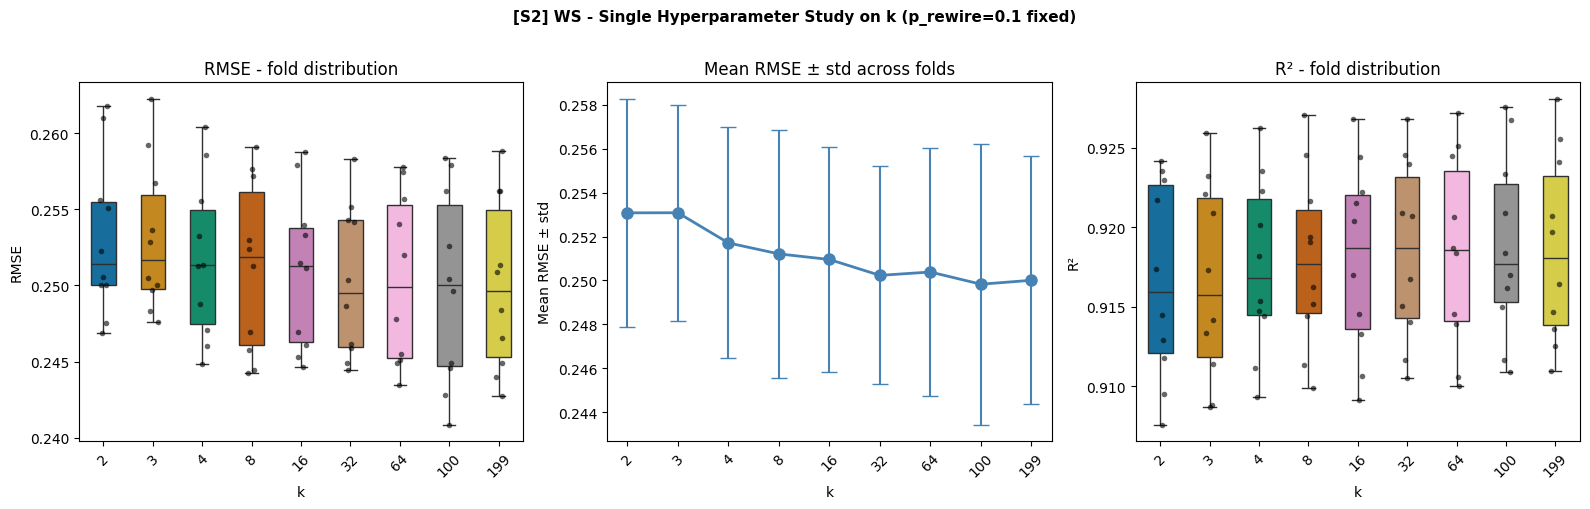


[WS] Sweeping rewiring prob p_rewire (k=4 fixed) ...
    [small_world] sweep 'p_rewire': 11 values x 10 folds = 110 evals
      [CLIP] p_rewire=0: sr_nat=3.070 → 1.100
      [CLIP] p_rewire=0.001: sr_nat=3.067 → 1.100
      [CLIP] p_rewire=0.005: sr_nat=3.538 → 1.100
      [CLIP] p_rewire=0.01: sr_nat=2.636 → 1.100
      [CLIP] p_rewire=0.02: sr_nat=2.603 → 1.100
      [CLIP] p_rewire=0.05: sr_nat=2.474 → 1.100
      [CLIP] p_rewire=0.1: sr_nat=3.024 → 1.100
      [CLIP] p_rewire=0.2: sr_nat=3.195 → 1.100
      [CLIP] p_rewire=0.3: sr_nat=3.012 → 1.100
      [CLIP] p_rewire=0.5: sr_nat=2.543 → 1.100
      [CLIP] p_rewire=1.0: sr_nat=2.691 → 1.100
    Figure saved → single_hp_outputs_3/shs_S2_ws_prw.png


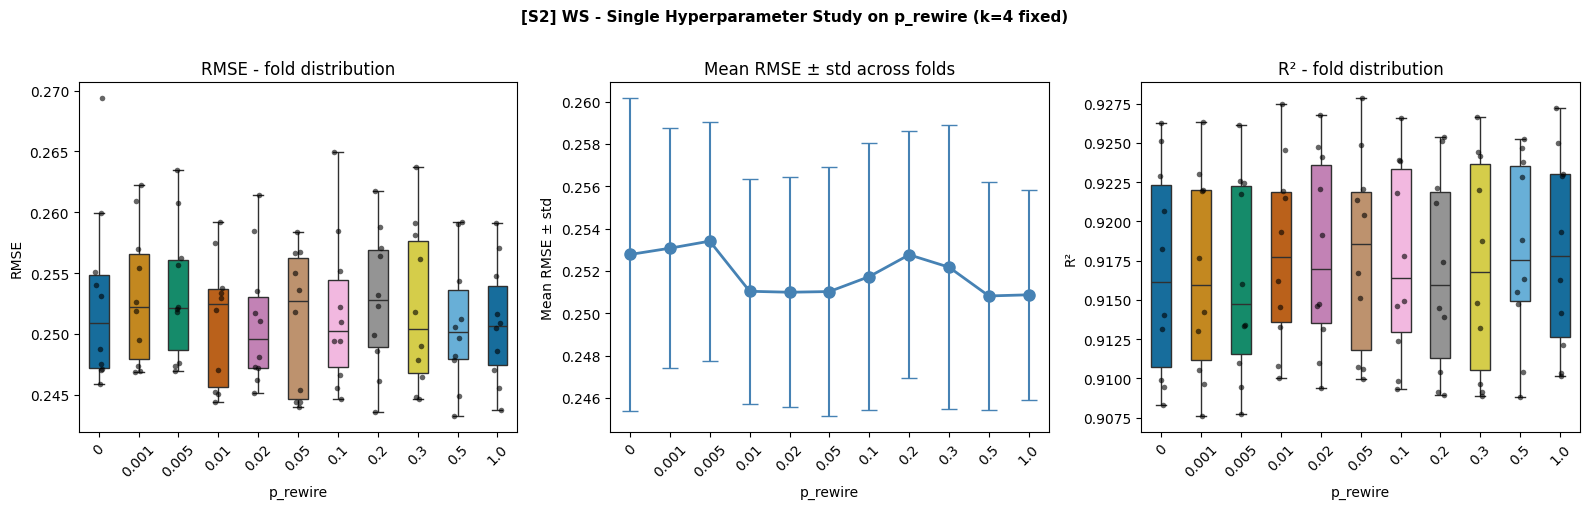


[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 11 values x 10 folds = 110 evals
      [CLIP] m=1: sr_nat=3.116 → 1.100
      [CLIP] m=2: sr_nat=2.905 → 1.100
      [CLIP] m=4: sr_nat=4.032 → 1.100
      [CLIP] m=8: sr_nat=5.087 → 1.100
      [CLIP] m=16: sr_nat=6.216 → 1.100
      [CLIP] m=32: sr_nat=8.230 → 1.100
      [CLIP] m=64: sr_nat=10.483 → 1.100
      [CLIP] m=100: sr_nat=11.414 → 1.100
      [CLIP] m=140: sr_nat=10.768 → 1.100
      [CLIP] m=180: sr_nat=9.065 → 1.100
      [CLIP] m=199: sr_nat=5.827 → 1.100
    Figure saved → single_hp_outputs_3/shs_S2_ba_m.png


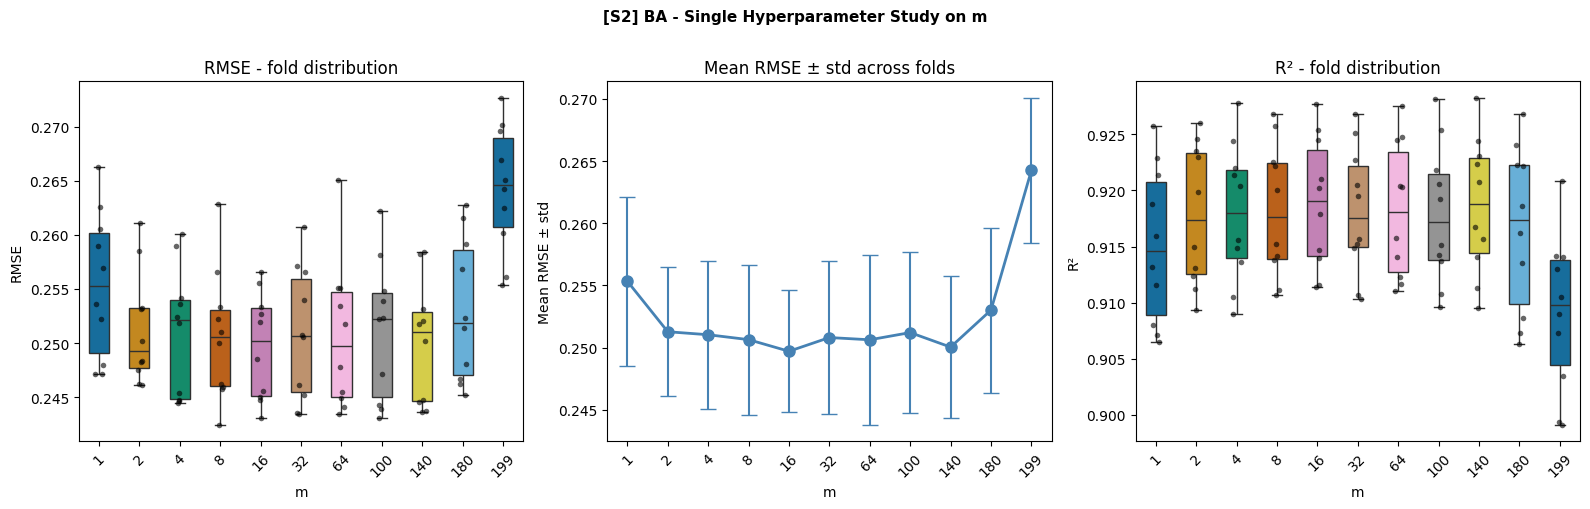


──────────────────────────────────────────────────────────────
  Best ER  : p=0.5          → mean RMSE = 0.24991
  Best WS  : k=100, p_rewire=0.5
              RMSE(k)=0.24983  RMSE(prw)=0.25082  best=0.24983
  Best BA  : m=16          → mean RMSE = 0.24970
  Elapsed  : 1.7 min


In [10]:
study_results["S2"] = run_signal_study(
    "S2", SIGNALS["S2"], BEST_PARAMS_PER_SIGNAL["S2"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
)

## 6. Topology Study - Signal S3
**6 frequencies + slow amplitude modulation (T_AM=5 000), sr=0.38** - in addition
to the increased spectral complexity, a slow sinusoidal envelope now modulates the
overall amplitude. This non-stationarity requires the reservoir to have both good
long-range memory (to track the slow AM) and sufficient fading memory (to suppress
outdated states).

Expected behaviour: the AM creates a qualitative change - architectures whose
natural SR is most robustly close to the edge of stability may show clearer
advantages. We expect larger inter-architecture RMSE differences than in S1/S2.


  S3 - 6 freq + AM, sr=0.38
  Slow amplitude modulation (T_AM=5 000)
  Dataset: X=(14990, 10)  y=(14990, 1)

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 11 values x 10 folds = 110 evals
      [CLIP] p=0.02: sr_nat=1.289 → 1.100
      [CLIP] p=0.05: sr_nat=2.429 → 1.100
      [CLIP] p=0.1: sr_nat=3.685 → 1.100
      [CLIP] p=0.2: sr_nat=4.544 → 1.100
      [CLIP] p=0.3: sr_nat=6.292 → 1.100
      [CLIP] p=0.5: sr_nat=7.578 → 1.100
      [CLIP] p=1.0: sr_nat=10.579 → 1.100
    Figure saved → single_hp_outputs_3/shs_S3_er_p.png


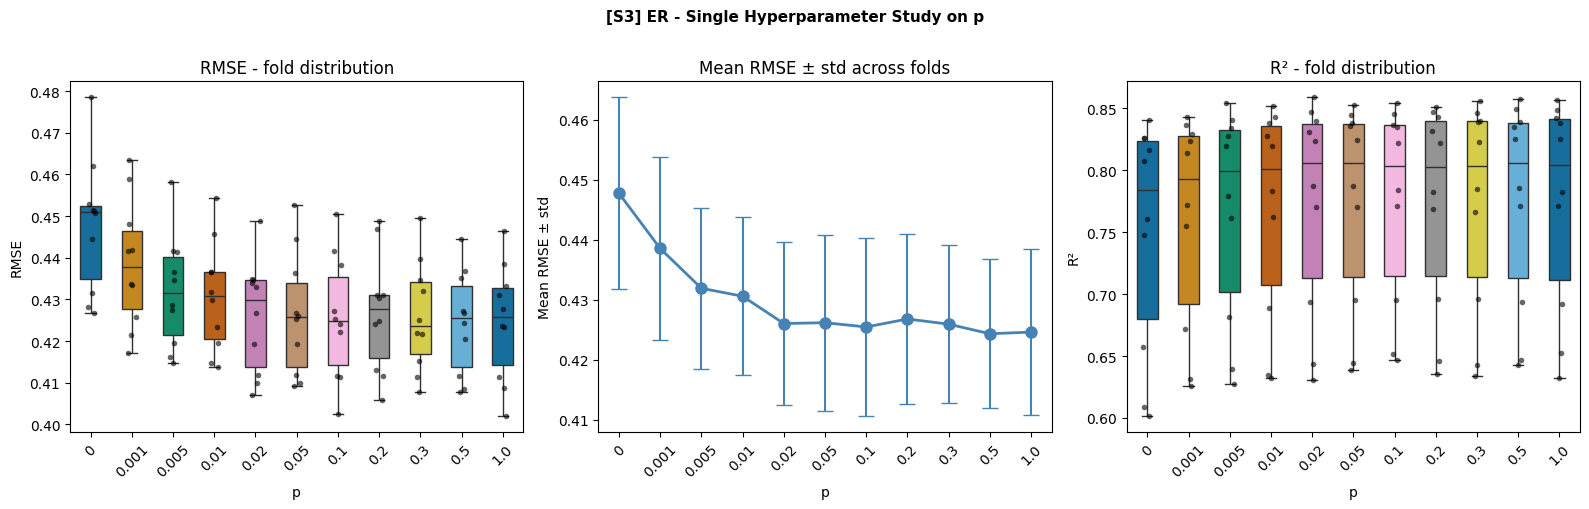


[WS] Sweeping mean degree k (p_rewire=0.1 fixed) ...
    [small_world] sweep 'k': 9 values x 10 folds = 90 evals
      [CLIP] k=2: sr_nat=2.886 → 1.100
      [CLIP] k=3: sr_nat=2.538 → 1.100
      [CLIP] k=4: sr_nat=2.599 → 1.100
      [CLIP] k=8: sr_nat=3.142 → 1.100
      [CLIP] k=16: sr_nat=4.297 → 1.100
      [CLIP] k=32: sr_nat=5.907 → 1.100
      [CLIP] k=64: sr_nat=8.533 → 1.100
      [CLIP] k=100: sr_nat=10.115 → 1.100
      [CLIP] k=199: sr_nat=10.754 → 1.100
    Figure saved → single_hp_outputs_3/shs_S3_ws_k.png


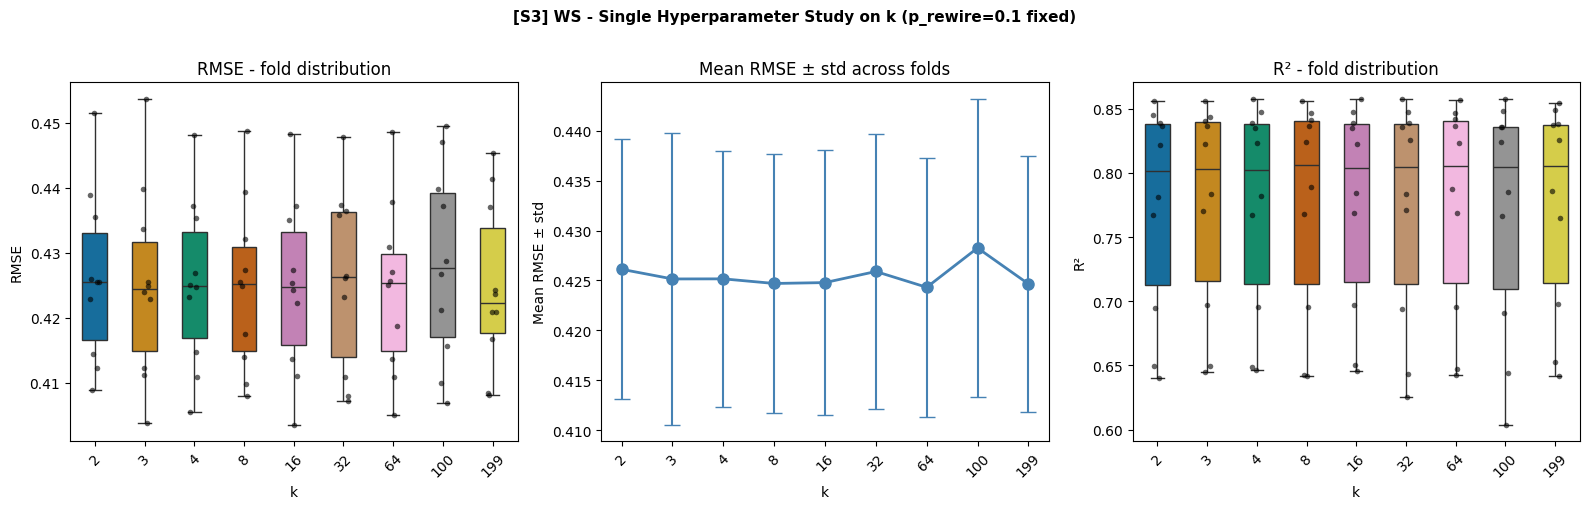


[WS] Sweeping rewiring prob p_rewire (k=4 fixed) ...
    [small_world] sweep 'p_rewire': 11 values x 10 folds = 110 evals
      [CLIP] p_rewire=0: sr_nat=2.746 → 1.100
      [CLIP] p_rewire=0.001: sr_nat=2.716 → 1.100
      [CLIP] p_rewire=0.005: sr_nat=2.715 → 1.100
      [CLIP] p_rewire=0.01: sr_nat=2.876 → 1.100
      [CLIP] p_rewire=0.02: sr_nat=3.209 → 1.100
      [CLIP] p_rewire=0.05: sr_nat=2.724 → 1.100
      [CLIP] p_rewire=0.1: sr_nat=2.962 → 1.100
      [CLIP] p_rewire=0.2: sr_nat=2.570 → 1.100
      [CLIP] p_rewire=0.3: sr_nat=2.565 → 1.100
      [CLIP] p_rewire=0.5: sr_nat=2.388 → 1.100
      [CLIP] p_rewire=1.0: sr_nat=2.767 → 1.100
    Figure saved → single_hp_outputs_3/shs_S3_ws_prw.png


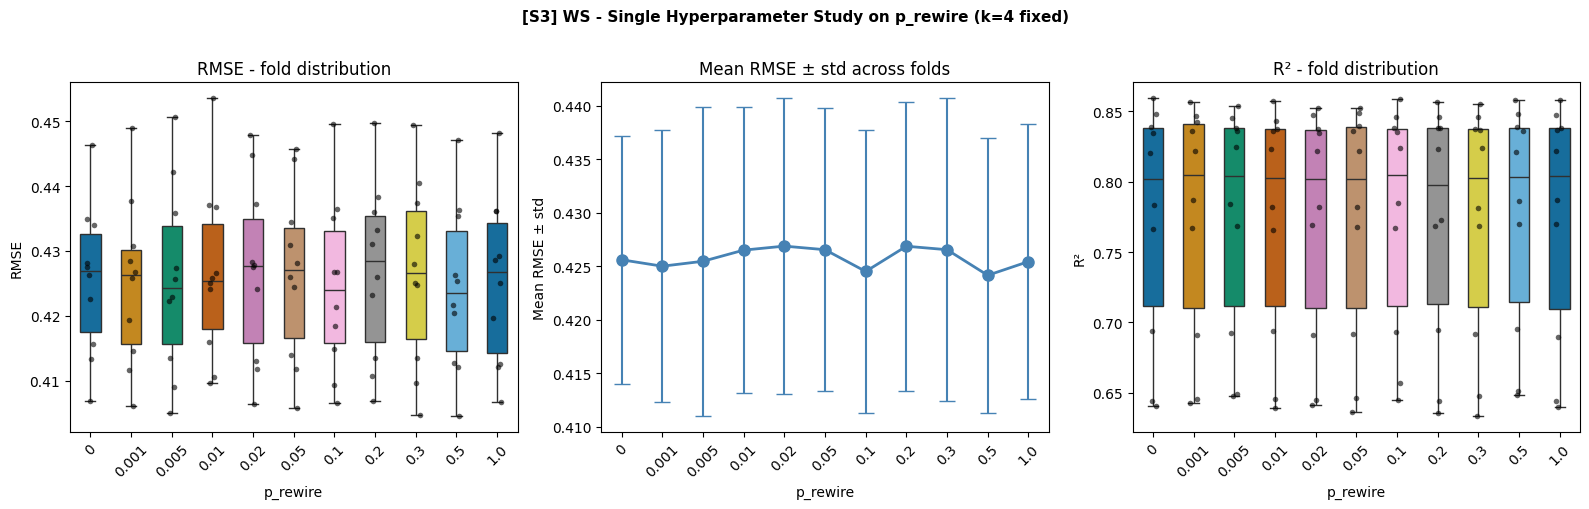


[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 11 values x 10 folds = 110 evals
      [CLIP] m=1: sr_nat=2.395 → 1.100
      [CLIP] m=2: sr_nat=3.192 → 1.100
      [CLIP] m=4: sr_nat=3.971 → 1.100
      [CLIP] m=8: sr_nat=4.409 → 1.100
      [CLIP] m=16: sr_nat=5.860 → 1.100
      [CLIP] m=32: sr_nat=7.552 → 1.100
      [CLIP] m=64: sr_nat=7.886 → 1.100
      [MATRIX ERROR] m=100: Barabási–Albert network must have m >= 1 and m < n, m = 100, n = 100
      [MATRIX ERROR] m=140: Barabási–Albert network must have m >= 1 and m < n, m = 140, n = 100
      [MATRIX ERROR] m=180: Barabási–Albert network must have m >= 1 and m < n, m = 180, n = 100
      [MATRIX ERROR] m=199: Barabási–Albert network must have m >= 1 and m < n, m = 199, n = 100
    Figure saved → single_hp_outputs_3/shs_S3_ba_m.png


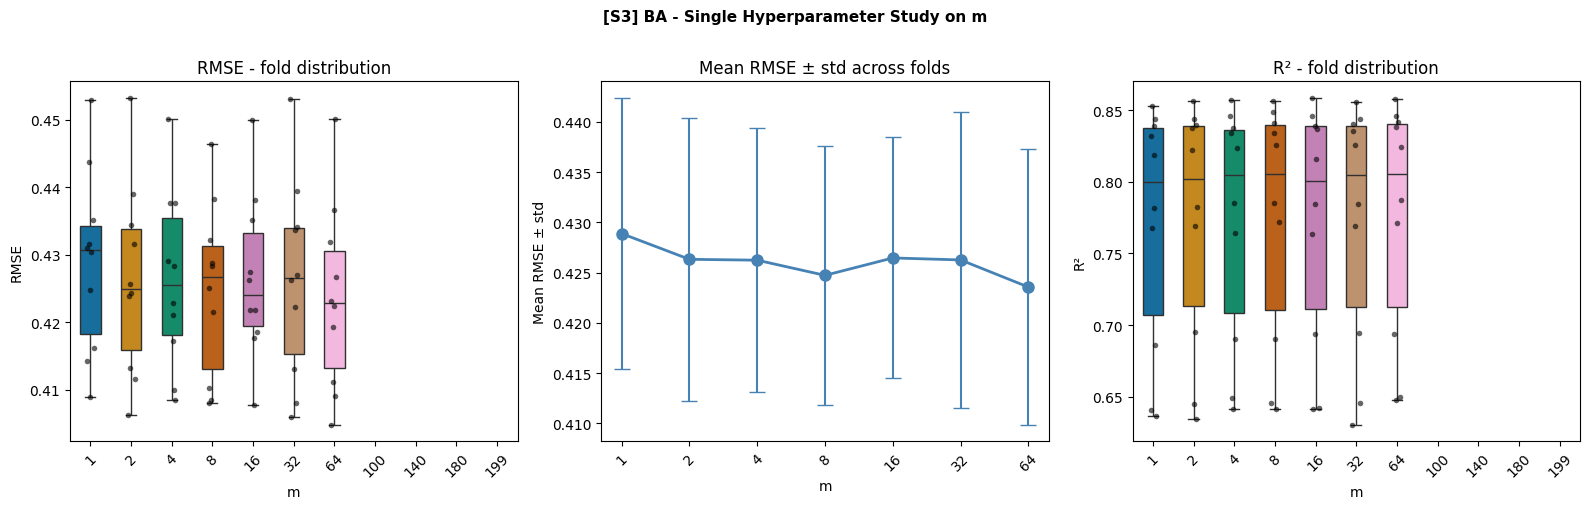


──────────────────────────────────────────────────────────────
  Best ER  : p=0.5          → mean RMSE = 0.42433
  Best WS  : k=64, p_rewire=0.5
              RMSE(k)=0.42432  RMSE(prw)=0.42416  best=0.42416
  Best BA  : m=64          → mean RMSE = 0.42356
  Elapsed  : 1.2 min


In [11]:
study_results["S3"] = run_signal_study(
    "S3", SIGNALS["S3"], BEST_PARAMS_PER_SIGNAL["S3"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
)

## 7. Topology Study - Signal S4
**7 frequencies + strong AM (T_AM=3 000), sr=0.56** - the hardest signal in this study.
T=37 generates beat frequencies that alias near T=127 and T=142, creating multi-scale
interference across different timescales simultaneously. The stronger AM envelope
(amplitude ±50%) compounds the non-stationarity.

Expected behaviour: all architectures degrade compared to easier signals, but the
relative ranking may flip from S1/S2 as the dominant bottleneck shifts from
spectral coverage to non-stationary adaptation.


  S4 - 7 freq + strong AM, sr=0.56
  Strong AM (T_AM=3 000) + dense multi-scale beating
  Dataset: X=(14990, 10)  y=(14990, 1)

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 11 values x 10 folds = 110 evals
      [CLIP] p=0.02: sr_nat=1.376 → 1.100
      [CLIP] p=0.05: sr_nat=2.339 → 1.100
      [CLIP] p=0.1: sr_nat=3.167 → 1.100
      [CLIP] p=0.2: sr_nat=4.504 → 1.100
      [CLIP] p=0.3: sr_nat=5.561 → 1.100
      [CLIP] p=0.5: sr_nat=7.429 → 1.100
      [CLIP] p=1.0: sr_nat=10.782 → 1.100
    Figure saved → single_hp_outputs_3/shs_S4_er_p.png


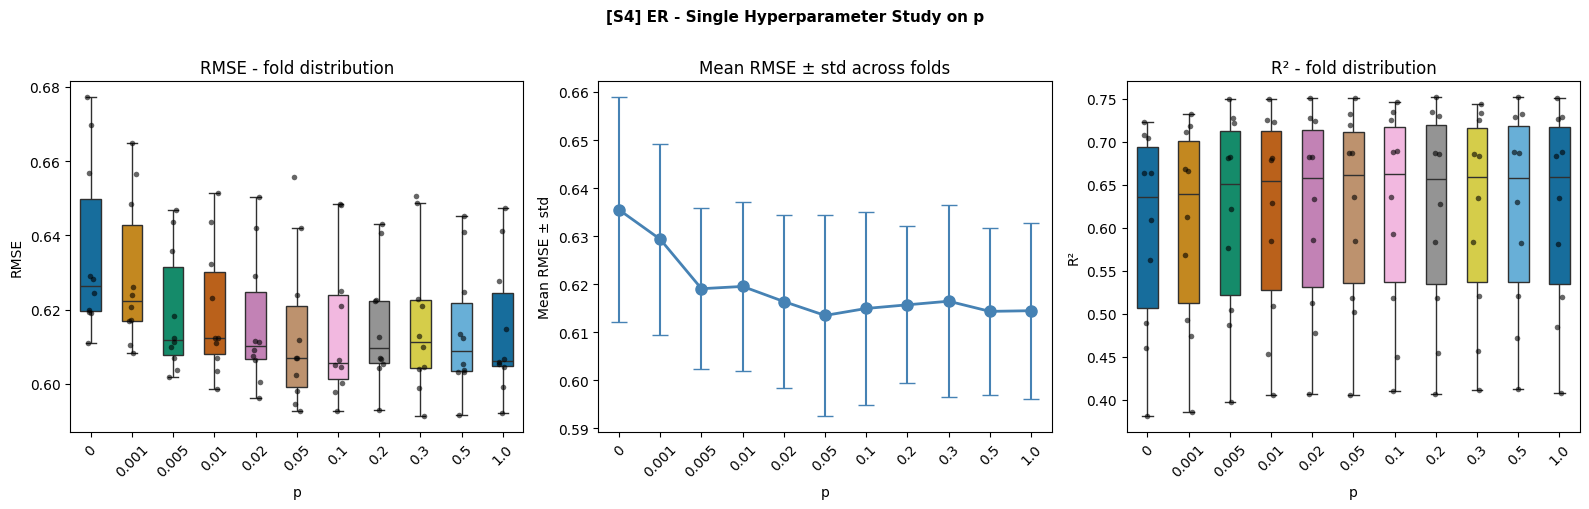


[WS] Sweeping mean degree k (p_rewire=0.1 fixed) ...
    [small_world] sweep 'k': 9 values x 10 folds = 90 evals
      [CLIP] k=2: sr_nat=2.785 → 1.100
      [CLIP] k=3: sr_nat=2.820 → 1.100
      [CLIP] k=4: sr_nat=2.786 → 1.100
      [CLIP] k=8: sr_nat=3.060 → 1.100
      [CLIP] k=16: sr_nat=4.961 → 1.100
      [CLIP] k=32: sr_nat=6.710 → 1.100
      [CLIP] k=64: sr_nat=9.261 → 1.100
      [CLIP] k=100: sr_nat=10.150 → 1.100
      [CLIP] k=199: sr_nat=9.791 → 1.100
    Figure saved → single_hp_outputs_3/shs_S4_ws_k.png


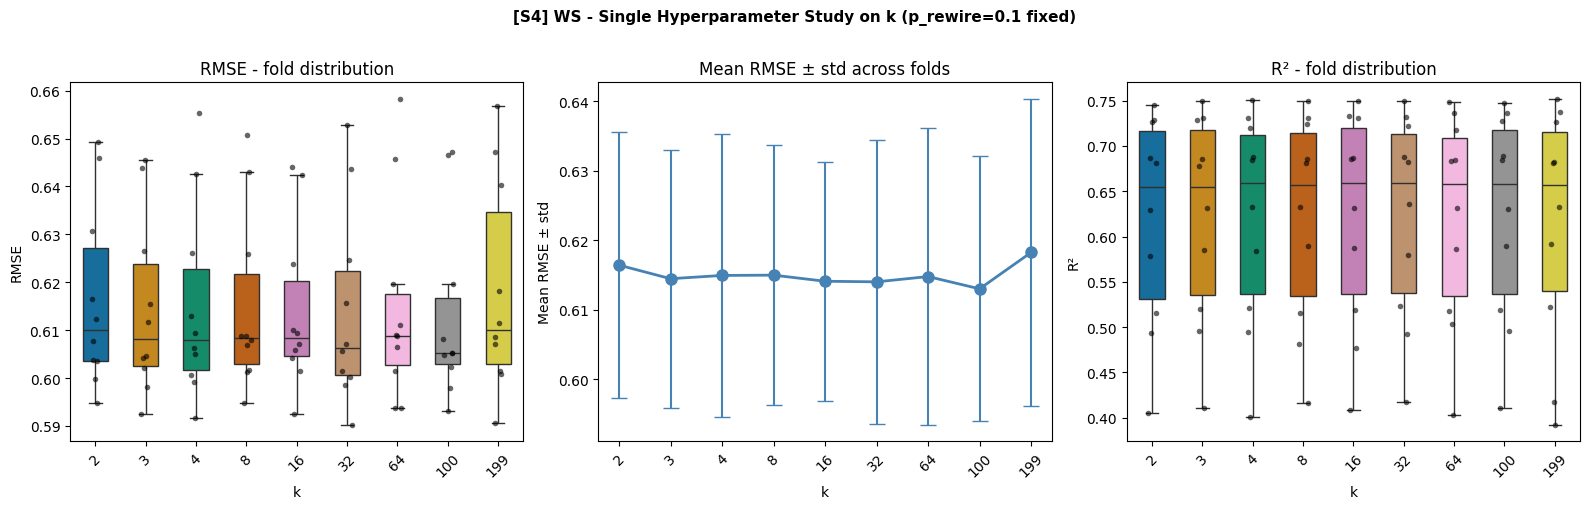


[WS] Sweeping rewiring prob p_rewire (k=4 fixed) ...
    [small_world] sweep 'p_rewire': 11 values x 10 folds = 110 evals
      [CLIP] p_rewire=0: sr_nat=2.578 → 1.100
      [CLIP] p_rewire=0.001: sr_nat=2.885 → 1.100
      [CLIP] p_rewire=0.005: sr_nat=3.442 → 1.100
      [CLIP] p_rewire=0.01: sr_nat=2.455 → 1.100
      [CLIP] p_rewire=0.02: sr_nat=2.490 → 1.100
      [CLIP] p_rewire=0.05: sr_nat=2.551 → 1.100
      [CLIP] p_rewire=0.1: sr_nat=2.777 → 1.100
      [CLIP] p_rewire=0.2: sr_nat=2.744 → 1.100
      [CLIP] p_rewire=0.3: sr_nat=3.110 → 1.100
      [CLIP] p_rewire=0.5: sr_nat=2.346 → 1.100
      [CLIP] p_rewire=1.0: sr_nat=2.490 → 1.100
    Figure saved → single_hp_outputs_3/shs_S4_ws_prw.png


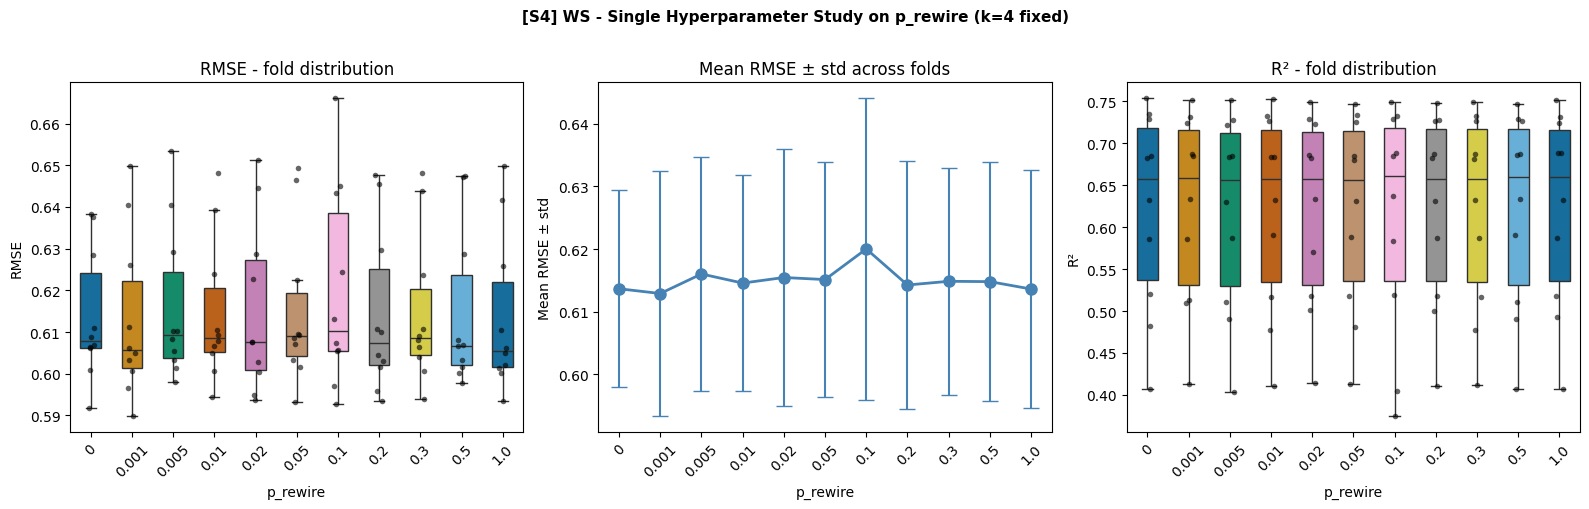


[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 11 values x 10 folds = 110 evals
      [CLIP] m=1: sr_nat=2.955 → 1.100
      [CLIP] m=2: sr_nat=2.652 → 1.100
      [CLIP] m=4: sr_nat=3.584 → 1.100
      [CLIP] m=8: sr_nat=4.149 → 1.100
      [CLIP] m=16: sr_nat=5.672 → 1.100
      [CLIP] m=32: sr_nat=7.299 → 1.100
      [CLIP] m=64: sr_nat=8.015 → 1.100
      [MATRIX ERROR] m=100: Barabási–Albert network must have m >= 1 and m < n, m = 100, n = 100
      [MATRIX ERROR] m=140: Barabási–Albert network must have m >= 1 and m < n, m = 140, n = 100
      [MATRIX ERROR] m=180: Barabási–Albert network must have m >= 1 and m < n, m = 180, n = 100
      [MATRIX ERROR] m=199: Barabási–Albert network must have m >= 1 and m < n, m = 199, n = 100
    Figure saved → single_hp_outputs_3/shs_S4_ba_m.png


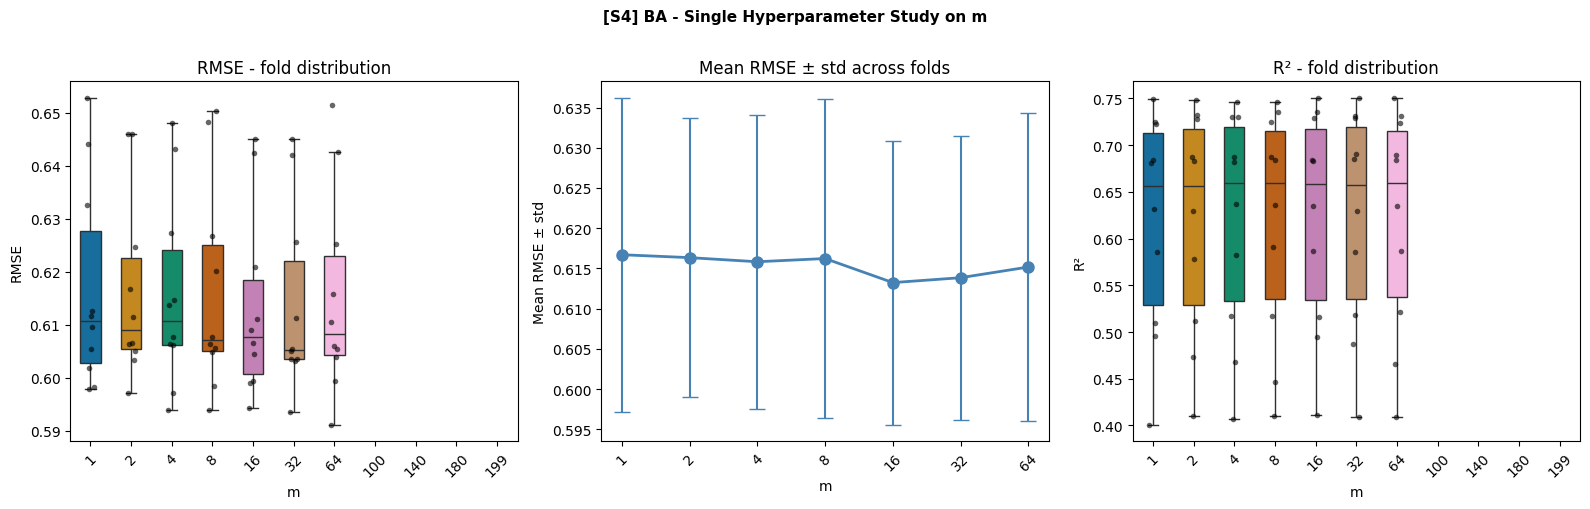


──────────────────────────────────────────────────────────────
  Best ER  : p=0.05          → mean RMSE = 0.61351
  Best WS  : k=100, p_rewire=0.001
              RMSE(k)=0.61300  RMSE(prw)=0.61290  best=0.61290
  Best BA  : m=16          → mean RMSE = 0.61323
  Elapsed  : 1.1 min


In [12]:
study_results["S4"] = run_signal_study(
    "S4", SIGNALS["S4"], BEST_PARAMS_PER_SIGNAL["S4"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
)

## 8. Cross-Signal Architecture Comparison Grid

This section collects the results from all four signal studies and builds the
comparison grid requested by the research objective:

1. **Summary table** - best RMSE and best structural parameter per (signal x architecture)
2. **Heatmap** - best RMSE as a function of signal difficulty x architecture
3. **SHS overlay** - sensitivity curves for each architecture, one plot per architecture
   overlaying all four signals to show how sensitivity shifts with complexity
4. **Best prediction plots** - qualitative comparison of real vs predicted signal
   for each (signal x architecture) at the best structural setting

In [13]:
# ---------------------------------------------------------------------------
# 8.1 Summary table - best RMSE and best param per (signal x architecture)
# ---------------------------------------------------------------------------
rows = []
for sig_name, res in study_results.items():
    sig_cfg = SIGNALS[sig_name]
    rows.append({
        "Signal":       sig_name,
        "Label":        res["label"],
        "n_freq":       res["n_components"],
        "noise_sr":      res["noise_std"],
        "Extra":        res["extra"],
        "ER best p":    res["ER"]["best_p"],
        "ER RMSE":      res["ER"]["best_rmse"],
        "WS best k":    res["WS_k"]["best_k"],
        "WS best prw":  res["WS_p"]["best_prw"],
        "WS RMSE":      res["WS_best_rmse"],
        "BA best m":    res["BA"]["best_m"],
        "BA RMSE":      res["BA"]["best_rmse"],
    })

df_summary = pd.DataFrame(rows).set_index("Signal")

print("Best RMSE per signal x architecture\n")
cols_show = ["Label", "n_freq", "noise_sr", "ER best p", "ER RMSE",
             "WS best k", "WS best prw", "WS RMSE", "BA best m", "BA RMSE"]
print(df_summary[cols_show].to_string(float_format="%.5f"))

df_summary.to_csv("single_hp_outputs_3/summary_best_rmse.csv")
print("\nSaved → single_hp_outputs_3/summary_best_rmse.csv")

Best RMSE per signal x architecture

                                   Label  n_freq  noise_sr  ER best p  ER RMSE  WS best k  WS best prw  WS RMSE  BA best m  BA RMSE
Signal                                                                                                                             
S1                  S1 - 4 freq, sr=0.12       4   0.12000    0.30000  0.13802         32      0.10000  0.13778        100  0.13821
S2        S2 - 5 freq + beating, sr=0.22       5   0.22000    0.50000  0.24991        100      0.50000  0.24983         16  0.24970
S3             S3 - 6 freq + AM, sr=0.38       6   0.38000    0.50000  0.42433         64      0.50000  0.42416         64  0.42356
S4      S4 - 7 freq + strong AM, sr=0.56       7   0.56000    0.05000  0.61351        100      0.00100  0.61290         16  0.61323

Saved → single_hp_outputs_3/summary_best_rmse.csv


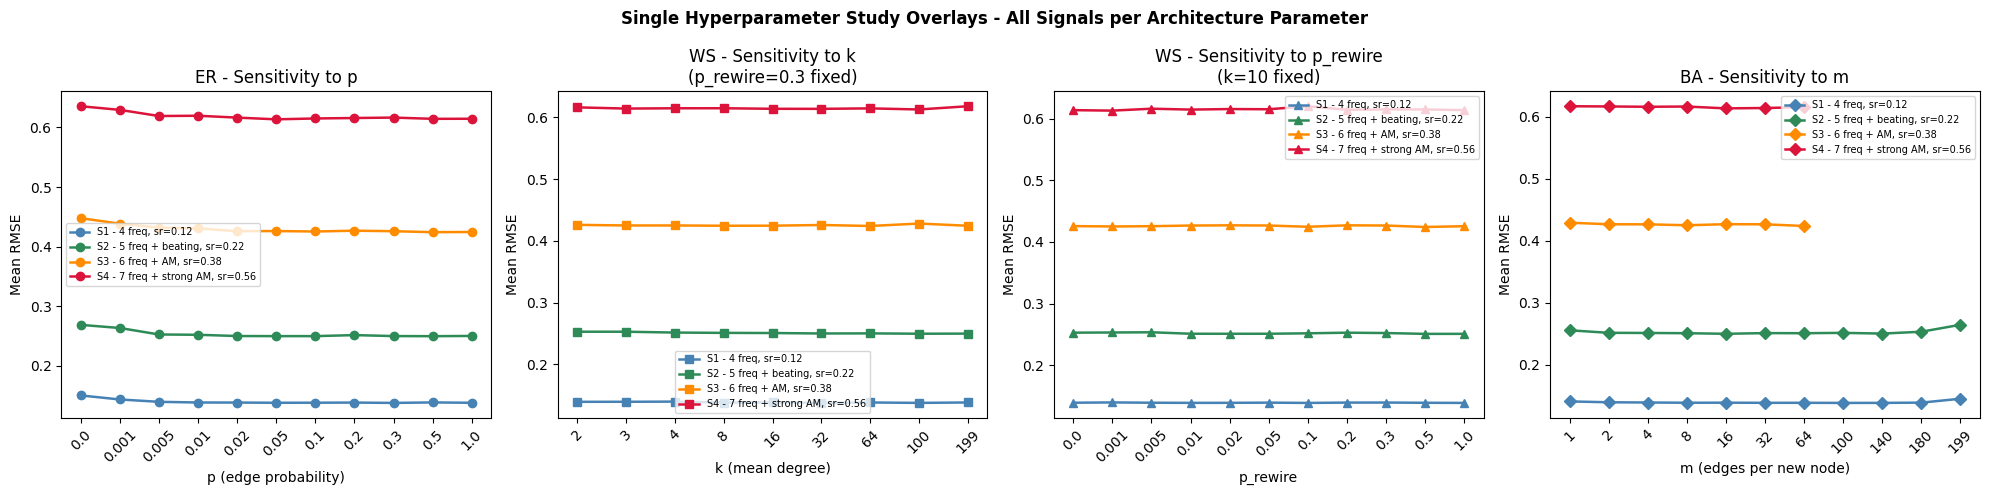

Figure saved → single_hp_outputs_3/comparison_shs_overlays.png


In [14]:
# ---------------------------------------------------------------------------
# 8.3 SHS overlay - one subplot per architecture, all signals overlaid
# Shows how parameter sensitivity shifts as signal difficulty increases.
# ---------------------------------------------------------------------------
sig_colors  = ["steelblue", "seagreen", "darkorange", "crimson",
               "purple", "brown", "pink", "gray", "olive", "cyan"]
sig_names   = list(study_results.keys())

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Single Hyperparameter Study Overlays - All Signals per Architecture Parameter",
             fontsize=12, fontweight="bold")

# ── ER: p ──
ax = axes[0]
for color, sig in zip(sig_colors, sig_names):
    df = study_results[sig]["ER"]["df"]
    agg = df.dropna(subset=["rmse"]).groupby("p")["rmse"].mean()
    ax.plot(agg.index.astype(str), agg.values, marker="o", color=color,
            label=study_results[sig]["label"], linewidth=1.8)
ax.set_title("ER - Sensitivity to p")
ax.set_xlabel("p (edge probability)")
ax.set_ylabel("Mean RMSE")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=7)

# ── WS: k ──
ax = axes[1]
for color, sig in zip(sig_colors, sig_names):
    df = study_results[sig]["WS_k"]["df"]
    agg = df.dropna(subset=["rmse"]).groupby("k")["rmse"].mean()
    ax.plot(agg.index.astype(str), agg.values, marker="s", color=color,
            label=study_results[sig]["label"], linewidth=1.8)
ax.set_title(f"WS - Sensitivity to k\n(p_rewire={FIXED_P_REWIRE} fixed)")
ax.set_xlabel("k (mean degree)")
ax.set_ylabel("Mean RMSE")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=7)

# ── WS: p_rewire ──
ax = axes[2]
for color, sig in zip(sig_colors, sig_names):
    df = study_results[sig]["WS_p"]["df"]
    agg = df.dropna(subset=["rmse"]).groupby("p_rewire")["rmse"].mean()
    ax.plot(agg.index.astype(str), agg.values, marker="^", color=color,
            label=study_results[sig]["label"], linewidth=1.8)
ax.set_title(f"WS - Sensitivity to p_rewire\n(k={FIXED_K} fixed)")
ax.set_xlabel("p_rewire")
ax.set_ylabel("Mean RMSE")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=7)

# ── BA: m ──
ax = axes[3]
for color, sig in zip(sig_colors, sig_names):
    df = study_results[sig]["BA"]["df"]
    agg = df.dropna(subset=["rmse"]).groupby("m")["rmse"].mean()
    ax.plot(agg.index.astype(str), agg.values, marker="D", color=color,
            label=study_results[sig]["label"], linewidth=1.8)
ax.set_title("BA - Sensitivity to m")
ax.set_xlabel("m (edges per new node)")
ax.set_ylabel("Mean RMSE")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("single_hp_outputs_3/comparison_shs_overlays.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figure saved → single_hp_outputs_3/comparison_shs_overlays.png")

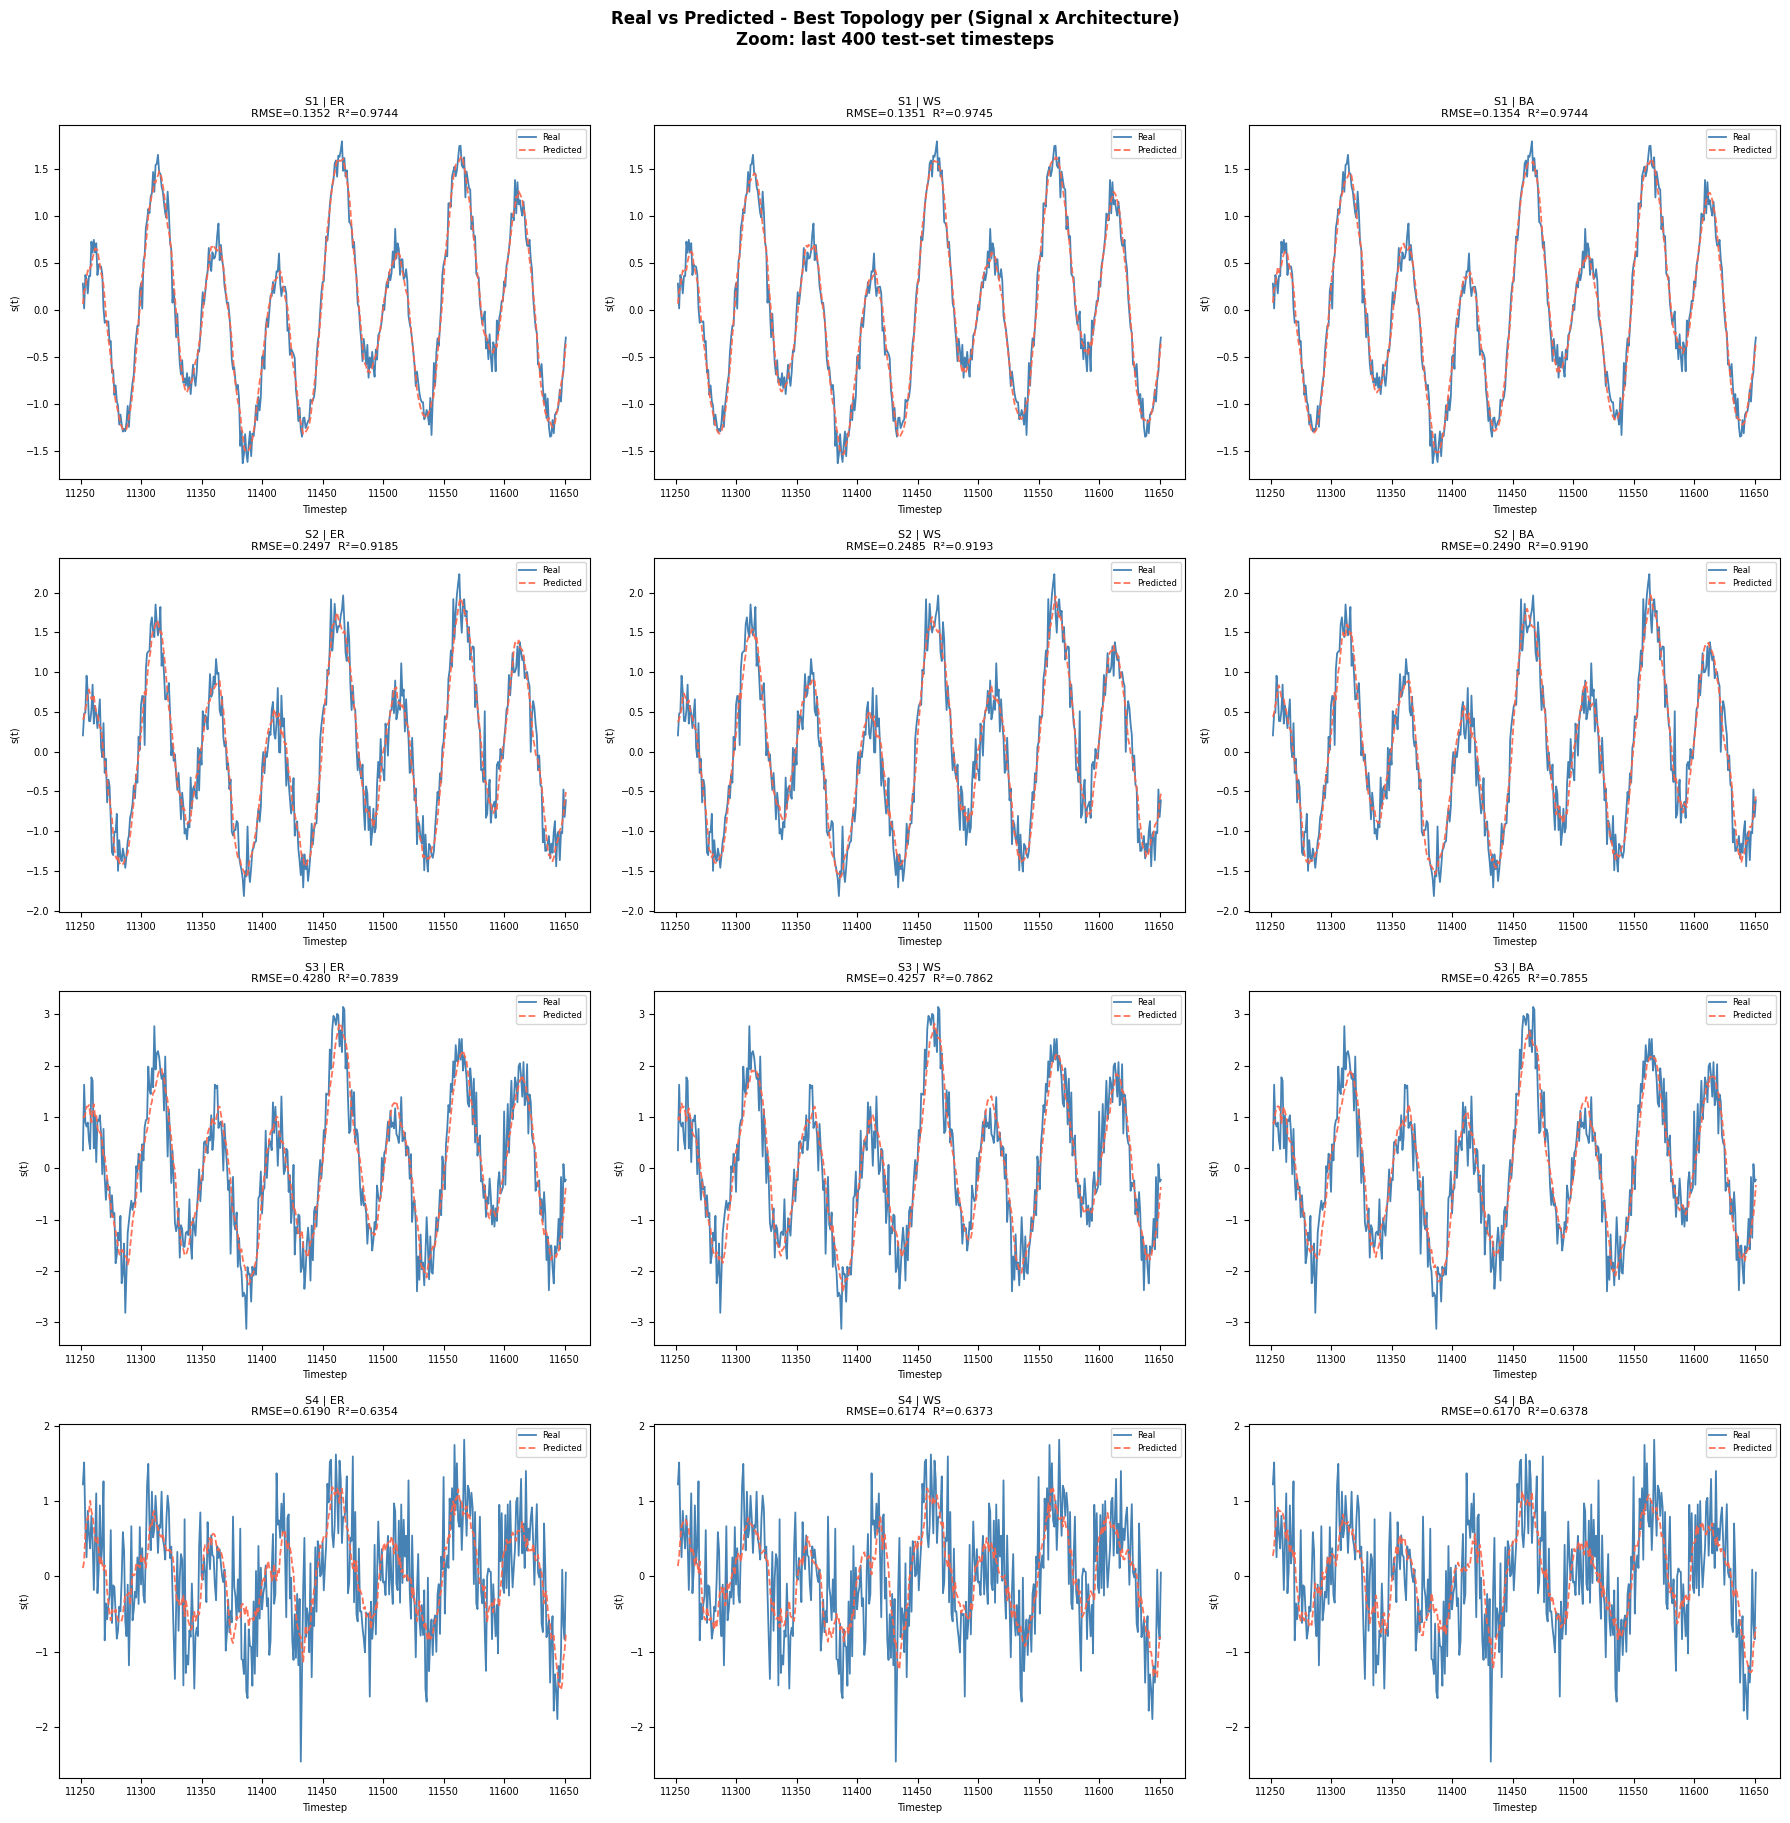

Figure saved → single_hp_outputs_3/prediction_grid.png


In [15]:
# ---------------------------------------------------------------------------
# 8.4 Prediction grid - best topology per (signal x architecture)
# N rows (signals) x 3 columns (architectures), each showing zoom of test set
# ---------------------------------------------------------------------------
arch_configs = [
    ("ER",  "random",      lambda res: {"p":   res["ER"]["best_p"]}),
    ("WS",  "small_world", lambda res: {"k":   res["WS_k"]["best_k"],
                                         "p_rewire": res["WS_p"]["best_prw"]}),
    ("BA",  "scale_free",  lambda res: {"m":   res["BA"]["best_m"]}),
]

fig, axes = plt.subplots(len(sig_names), len(arch_configs),
                          figsize=(18, 4.5 * len(sig_names)))
fig.suptitle("Real vs Predicted - Best Topology per (Signal x Architecture)\n"
             "Zoom: last 400 test-set timesteps",
             fontsize=12, fontweight="bold", y=1.01)

for row, sig_name in enumerate(sig_names):
    res     = study_results[sig_name]
    sig_cfg = SIGNALS[sig_name]
    signal  = sig_cfg["data"]
    X_all_s, y_all_s = build_dataset(signal, lag=LAG)
    n        = len(X_all_s)
    n_train  = int(n * 0.75)
    X_te_s, y_te_s = X_all_s[n_train:], y_all_s[n_train:]
    t_test   = np.arange(len(signal))[LAG + n_train:]
    zoom     = 400

    for col, (arch_name, topo_str, get_params) in enumerate(arch_configs):
        ax = axes[row, col]
        topo_params = get_params(res)

        try:
            W, _ = make_reservoir_matrix(BEST_PARAMS["N"], topo_str, topo_params)
            scaler    = StandardScaler()
            X_tr_all  = scaler.fit_transform(X_all_s[:n_train])
            X_te_all  = scaler.transform(X_te_s)
            reservoir = Reservoir(units=BEST_PARAMS["N"], W=W, lr=BEST_PARAMS["lr"])
            model     = reservoir >> Ridge(ridge=BEST_PARAMS["ridge"])
            model.fit(X_tr_all, y_all_s[:n_train], warmup=int(BEST_PARAMS["washout"]))
            y_pred = np.array(model.run(X_te_all)).reshape(-1)
            y_true = y_te_s.ravel()
            rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
            r2     = r2_score(y_true, y_pred)

            ax.plot(t_test[:zoom], y_true[:zoom], lw=1.3, color="steelblue", label="Real")
            ax.plot(t_test[:zoom], y_pred[:zoom], lw=1.3, color="tomato",
                    ls="--", alpha=0.9, label="Predicted")
            ax.set_title(f"{sig_name} | {arch_name}\nRMSE={rmse:.4f}  R²={r2:.4f}", fontsize=8)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error:\n{e}", transform=ax.transAxes,
                    ha="center", va="center", fontsize=7, color="red")
            ax.set_title(f"{sig_name} | {arch_name}", fontsize=8)

        ax.set_xlabel("Timestep", fontsize=7)
        ax.set_ylabel("s(t)", fontsize=7)
        ax.legend(fontsize=6)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("single_hp_outputs_3/prediction_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved → single_hp_outputs_3/prediction_grid.png")

In [18]:
# ---------------------------------------------------------------------------
# 8.5 Architecture ranking - how often each topology wins across signals
# ---------------------------------------------------------------------------
print("Architecture ranking (best RMSE wins per signal)\n")
print(f"{'Signal':<40}  {'Winner':<18}  RMSE")
print("─" * 65)

wins = {"ER": 0, "WS": 0, "BA": 0}
for sig in sig_names:
    res = study_results[sig]
    rmse_dict = {
        "ER":  res["ER"]["best_rmse"],
        "WS":  res["WS_best_rmse"],
        "BA":  res["BA"]["best_rmse"],
    }
    winner = min(rmse_dict, key=rmse_dict.get)
    wins[winner] += 1
    label = res["label"]
    print(f"  {label:<38}  {winner:<18}  {rmse_dict[winner]:.5f}")

print("─" * 65)
print(f"  Wins:  ER={wins['ER']}  WS={wins['WS']}  BA={wins['BA']}")

# Relative degradation from S1 to S4
print("\nRelative RMSE degradation S1 → S4:")
for arch, key in [("ER", "ER"), ("WS", "WS_best_rmse" if False else None), ("BA", "BA")]:
    rmse_s1 = study_results["S1"][key]["best_rmse"] if key else study_results["S1"]["WS_best_rmse"]
    rmse_s4 = study_results["S4"][key]["best_rmse"] if key else study_results["S4"]["WS_best_rmse"]
    if arch == "WS":
        rmse_s1 = study_results["S1"]["WS_best_rmse"]
        rmse_s4 = study_results["S4"]["WS_best_rmse"]
    pct = 100.0 * (rmse_s4 - rmse_s1) / rmse_s1
    print(f"  {arch}: {rmse_s1:.5f} → {rmse_s4:.5f}  (+{pct:.1f}%)")

Architecture ranking (best RMSE wins per signal)

Signal                                    Winner              RMSE
─────────────────────────────────────────────────────────────────
  S1 - 4 freq, sr=0.12                    WS                  0.13778
  S2 - 5 freq + beating, sr=0.22          BA                  0.24970
  S3 - 6 freq + AM, sr=0.38               BA                  0.42356
  S4 - 7 freq + strong AM, sr=0.56        WS                  0.61290
─────────────────────────────────────────────────────────────────
  Wins:  ER=0  WS=2  BA=2

Relative RMSE degradation S1 → S4:
  ER: 0.13802 → 0.61351  (+344.5%)
  WS: 0.13778 → 0.61290  (+344.8%)
  BA: 0.13821 → 0.61323  (+343.7%)


## 9. Final Comparison — Mean RMSE vs. Signal Difficulty

Using the **canonical best topology parameters** fixed in Section 3.3, we evaluate all three
architectures on an **extended 20-signal benchmark** under the same **10-fold temporal CV**
protocol.

The first ten signals are the original suite. This section appends **S11-S20**, each adding one
more sine component plus slower near-period pairs and stronger multi-scale amplitude modulation,
so the forecasting task becomes harder and more long-memory dependent.

- **x-axis** — signal difficulty rank (`S1` ... `S20`), with labels showing the number of sine components
- **top panel** — mean RMSE across 10 CV folds for ER, WS, and BA (`+/- 1 std` shaded band)
- **bottom panel** — architecture spread (`worst RMSE - best RMSE`) so any separation between
  topologies is easier to spot
- **goal** — check whether the added long-memory signals create clearer differences between
  reservoir architectures


Evaluating architectures with canonical params across 20 signals (10-fold CV) ...

[ER]  topology=random  params={'p': np.float64(0.3)}  density=0.299
  S1: mean RMSE = 0.13817 +/- 0.00229
  S2: mean RMSE = 0.25214 +/- 0.00681
  S3: mean RMSE = 0.42886 +/- 0.01507
  S4: mean RMSE = 0.62260 +/- 0.02543
  S5: mean RMSE = 0.78425 +/- 0.02030
  S6: mean RMSE = 0.94466 +/- 0.04160
  S7: mean RMSE = 1.09442 +/- 0.02326
  S8: mean RMSE = 1.31258 +/- 0.04129
  S9: mean RMSE = 1.61776 +/- 0.05808
  S10: mean RMSE = 2.12607 +/- 0.08747
  S11: mean RMSE = 2.27803 +/- 0.08166
  S12: mean RMSE = 2.40332 +/- 0.12993
  S13: mean RMSE = 2.51835 +/- 0.11317
  S14: mean RMSE = 2.60658 +/- 0.10388
  S15: mean RMSE = 2.70193 +/- 0.08406
  S16: mean RMSE = 2.80770 +/- 0.11010
  S17: mean RMSE = 2.91040 +/- 0.11704
  S18: mean RMSE = 3.01541 +/- 0.10910
  S19: mean RMSE = 3.11444 +/- 0.06958
  S20: mean RMSE = 3.22974 +/- 0.15704

[WS]  topology=small_world  params={'k': np.int64(64), 'p_rewire': np.float64

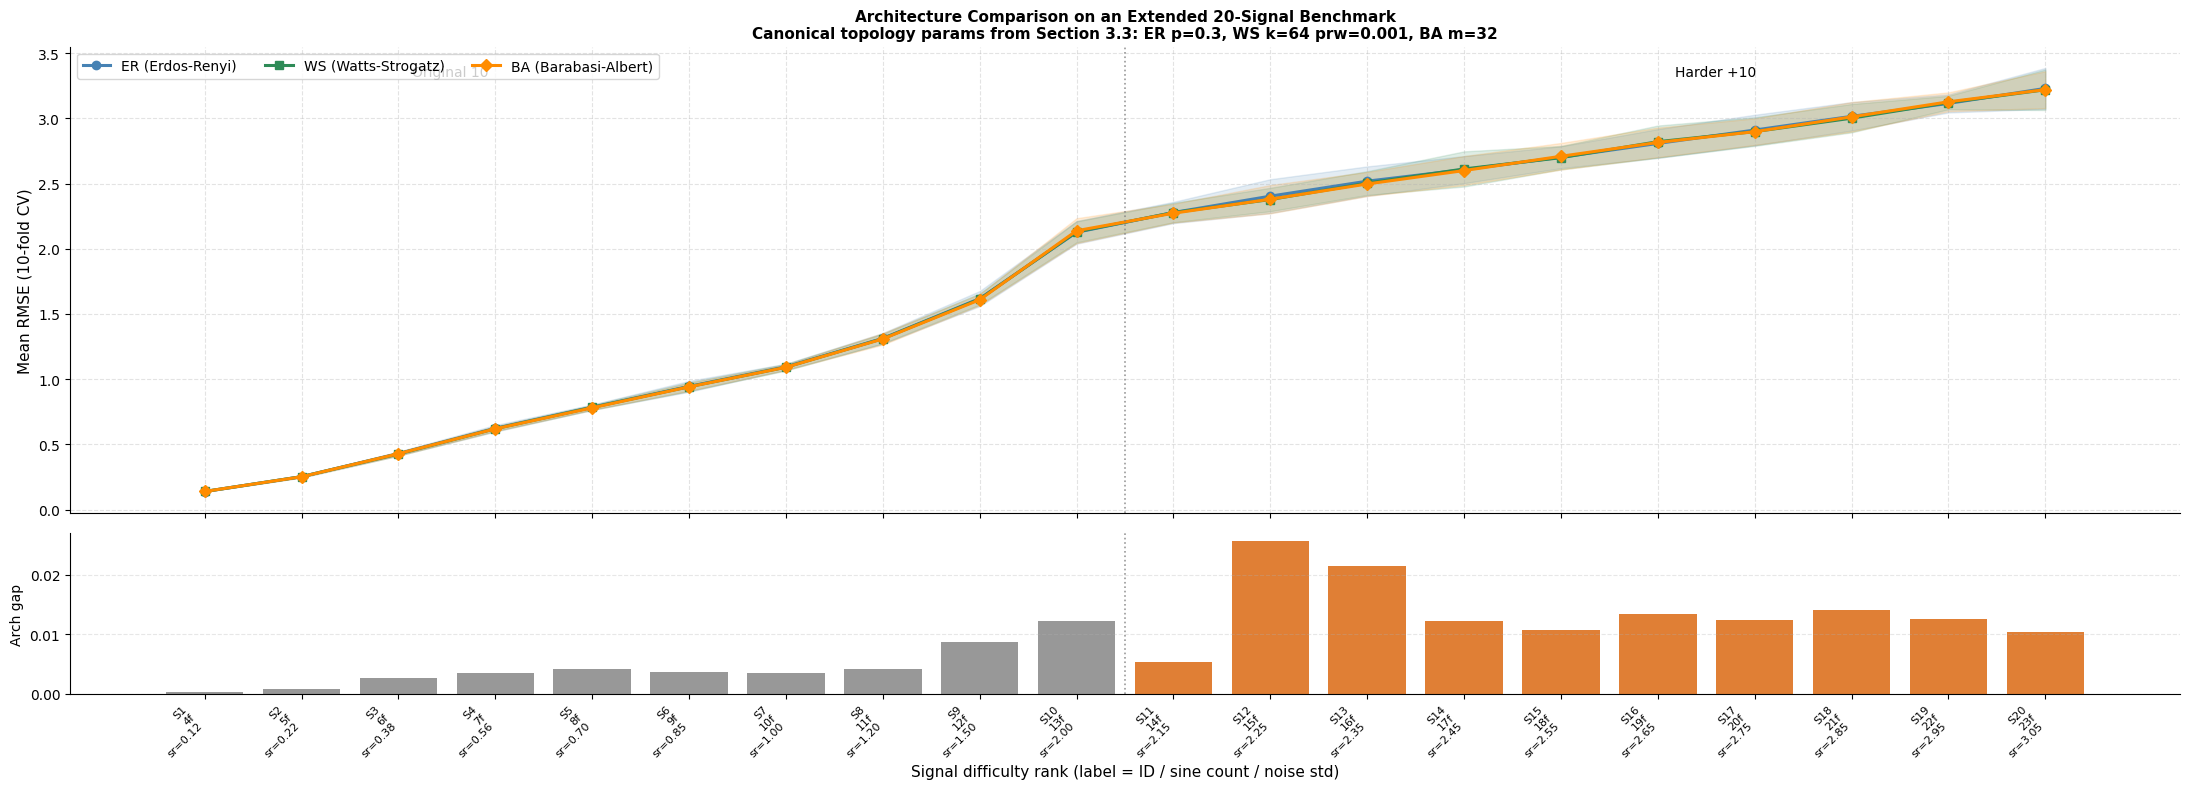

Figure saved -> single_hp_outputs_3/final_rmse_vs_difficulty.png

Mean RMSE per signal x architecture [canonical params]

Signal    Suite  n_freq  noise_sr  memory_scale  ER RMSE  WS RMSE  BA RMSE Winner  Arch gap
    S1 original       4   0.12000           310  0.13817  0.13830  0.13847     ER   0.00030
    S2 original       5   0.22000           883  0.25214  0.25195  0.25134     BA   0.00080
    S3 original       6   0.38000          5000  0.42886  0.42624  0.42803     WS   0.00262
    S4 original       7   0.56000          3000  0.62260  0.62012  0.61916     BA   0.00344
    S5 original       8   0.70000          2000  0.78425  0.78327  0.78017     BA   0.00408
    S6 original       9   0.85000          1500  0.94466  0.94200  0.94100     BA   0.00366
    S7 original      10   1.00000          2500  1.09442  1.09150  1.09094     BA   0.00348
    S8 original      11   1.20000          3500  1.31258  1.31064  1.30842     BA   0.00415
    S9 original      12   1.50000          4000  1

In [19]:
# ---------------------------------------------------------------------------
# Evaluate an extended 20-signal benchmark with canonical best params
# ---------------------------------------------------------------------------
canonical_topo = {
    "ER": ("random",      {"p": CANONICAL_ER_P}),
    "WS": ("small_world", {"k": CANONICAL_WS_K,
                             "p_rewire": CANONICAL_WS_PRW}),
    "BA": ("scale_free",  {"m": CANONICAL_BA_M}),
}

# ---------------------------------------------------------------------------
# Section 9 only: extend the benchmark with 10 harder long-memory signals.
# This leaves the earlier SIGNALS dict untouched for Sections 2-8.
# ---------------------------------------------------------------------------
baseline_memory_scale = {
    "S1": 310,
    "S2": 883,
    "S3": 5000,
    "S4": 3000,
    "S5": 2000,
    "S6": 1500,
    "S7": 2500,
    "S8": 3500,
    "S9": 4000,
    "S10": 5000,
}

benchmark_signals = {
    name: {**cfg, "suite": "original", "memory_scale": baseline_memory_scale[name]}
    for name, cfg in SIGNALS.items()
}

hard_periods = [50, 127, 310, 83, 53, 200, 37, 19, 71, 29, 13, 97, 43,
                149, 157, 233, 241, 421, 433, 610, 631, 887, 911]
hard_amps = [1.00, 0.50, 0.30, 0.25, 0.20, 0.15, 0.12, 0.10, 0.08, 0.07, 0.06,
             0.05, 0.04, 0.035, 0.032, 0.028, 0.026, 0.022, 0.020, 0.018, 0.016,
             0.014, 0.012]
hard_noise = np.linspace(2.15, 3.05, 10)
beat_pairs = [(149, 157), (233, 241), (421, 433), (610, 631), (887, 911)]
rng_ext = np.random.default_rng(20260325)

for offset in range(10):
    sig_idx = 11 + offset
    n_components = 14 + offset
    periods = hard_periods[:n_components]
    amps = hard_amps[:n_components]

    carrier = np.zeros(T)
    for comp_idx, (amp, period) in enumerate(zip(amps, periods), start=1):
        phase = 0.17 * comp_idx
        carrier += amp * np.sin(2 * np.pi * t_axis / period + phase)

    env_periods = [5200 + 140 * offset, 320 + 12 * offset]
    env_strengths = [0.90 + 0.005 * offset, 0.62 + 0.015 * offset]
    if offset >= 2:
        env_periods.append(1400 + 90 * offset)
        env_strengths.append(0.16 + 0.01 * offset)

    envelope = np.ones(T)
    for env_idx, (env_amp, env_period) in enumerate(zip(env_strengths, env_periods), start=1):
        envelope *= 1.0 + env_amp * np.sin(
            2 * np.pi * t_axis / env_period + 0.3 * env_idx
        )

    signal = envelope * carrier + hard_noise[offset] * rng_ext.standard_normal(T)

    active_pairs = []
    beat_scales = []
    for p1, p2 in beat_pairs:
        if p1 in periods and p2 in periods:
            active_pairs.append(f"{p1}/{p2}")
            beat_scales.append(int(round((p1 * p2) / abs(p2 - p1))))
    memory_scale = max(env_periods + periods + beat_scales)

    desc_bits = []
    if active_pairs:
        desc_bits.append("near-period beats " + ", ".join(active_pairs))
    else:
        desc_bits.append(f"new slow mode T={periods[-1]}")
    desc_bits.append("triple AM" if len(env_periods) == 3 else "double AM")

    benchmark_signals[f"S{sig_idx}"] = {
        "data": signal,
        "label": f"S{sig_idx} - {n_components} freq + long-memory beats, sr={hard_noise[offset]:.2f}",
        "desc": f"{n_components} sine components with slow beating and multi-scale envelopes",
        "n_components": n_components,
        "noise_std": float(hard_noise[offset]),
        "extra": "; ".join(desc_bits),
        "suite": "extended",
        "memory_scale": memory_scale,
    }

results_final = {}
tscv_final = TimeSeriesSplit(n_splits=N_SPLITS)

print(
    f"Evaluating architectures with canonical params across {len(benchmark_signals)} signals "
    f"({N_SPLITS}-fold CV) ...\n"
)

for arch_name, (topology, topo_params) in canonical_topo.items():
    results_final[arch_name] = {}
    W, info = make_reservoir_matrix(BEST_PARAMS["N"], topology, topo_params)
    print(
        f"[{arch_name}]  topology={topology}  params={topo_params}"
        f"  density={info['actual_density']:.3f}"
    )

    for sig_name, sig_cfg in benchmark_signals.items():
        X_s, y_s = build_dataset(sig_cfg["data"], lag=LAG)
        fold_rmses = []

        for train_idx, test_idx in tscv_final.split(X_s):
            X_tr_f, y_tr_f = X_s[train_idx], y_s[train_idx]
            X_te_f, y_te_f = X_s[test_idx], y_s[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            reservoir = Reservoir(units=BEST_PARAMS["N"], W=W, lr=BEST_PARAMS["lr"])
            model = reservoir >> Ridge(ridge=BEST_PARAMS["ridge"])
            model.fit(X_tr, y_tr_f, warmup=int(BEST_PARAMS["washout"]))
            y_pred = np.array(model.run(X_te)).reshape(-1)
            fold_rmses.append(np.sqrt(mean_squared_error(y_te_f.ravel(), y_pred)))

        results_final[arch_name][sig_name] = {
            "mean": float(np.mean(fold_rmses)),
            "std": float(np.std(fold_rmses)),
            "folds": fold_rmses,
        }
        print(
            f"  {sig_name}: mean RMSE = {np.mean(fold_rmses):.5f} +/- {np.std(fold_rmses):.5f}"
        )
    print()

# ---------------------------------------------------------------------------
# Plot - Mean RMSE vs. signal difficulty, plus architecture spread per signal
# ---------------------------------------------------------------------------
sig_order = list(benchmark_signals.keys())
x_pos = np.arange(len(sig_order))
x_labels = [
    f"{s}\n{benchmark_signals[s]['n_components']}f\nsr={benchmark_signals[s]['noise_std']:.2f}"
    for s in sig_order
]

arch_styles = {
    "ER": {"color": "steelblue",  "marker": "o", "label": "ER (Erdos-Renyi)"},
    "WS": {"color": "seagreen",   "marker": "s", "label": "WS (Watts-Strogatz)"},
    "BA": {"color": "darkorange", "marker": "D", "label": "BA (Barabasi-Albert)"},
}

fig, (ax_main, ax_gap) = plt.subplots(
    2,
    1,
    figsize=(22, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1.1]},
)

for arch_name, style in arch_styles.items():
    means = [results_final[arch_name][s]["mean"] for s in sig_order]
    stds = [results_final[arch_name][s]["std"] for s in sig_order]

    ax_main.plot(
        x_pos,
        means,
        color=style["color"],
        marker=style["marker"],
        linewidth=2.2,
        markersize=6,
        label=style["label"],
    )
    ax_main.fill_between(
        x_pos,
        [m - sd for m, sd in zip(means, stds)],
        [m + sd for m, sd in zip(means, stds)],
        color=style["color"],
        alpha=0.15,
    )

spread_vals = []
for s in sig_order:
    rmse_map = {arch: results_final[arch][s]["mean"] for arch in arch_styles}
    spread_vals.append(max(rmse_map.values()) - min(rmse_map.values()))

gap_colors = [
    "#7f7f7f" if benchmark_signals[s]["suite"] == "original" else "#d95f02"
    for s in sig_order
]
ax_gap.bar(x_pos, spread_vals, color=gap_colors, alpha=0.80)

split_x = len(SIGNALS) - 0.5
for ax in (ax_main, ax_gap):
    ax.axvline(split_x, color="gray", linestyle=":", linewidth=1.2, alpha=0.8)

ax_main.text(0.18, 0.96, "Original 10", transform=ax_main.transAxes,
             ha="center", va="top", fontsize=10)
ax_main.text(0.78, 0.96, "Harder +10", transform=ax_main.transAxes,
             ha="center", va="top", fontsize=10)

ax_main.set_ylabel(f"Mean RMSE ({N_SPLITS}-fold CV)", fontsize=11)
ax_main.set_title(
    "Architecture Comparison on an Extended 20-Signal Benchmark\n"
    f"Canonical topology params from Section 3.3: "
    f"ER p={CANONICAL_ER_P}, WS k={CANONICAL_WS_K} prw={CANONICAL_WS_PRW}, BA m={CANONICAL_BA_M}",
    fontsize=11,
    fontweight="bold",
)
ax_main.grid(True, linestyle="--", alpha=0.35)
ax_main.legend(fontsize=10, ncol=3, loc="upper left")

ax_gap.set_ylabel("Arch gap", fontsize=10)
ax_gap.set_xlabel("Signal difficulty rank (label = ID / sine count / noise std)", fontsize=11)
ax_gap.set_xticks(x_pos)
ax_gap.set_xticklabels(x_labels, fontsize=8, rotation=45, ha="right")
ax_gap.grid(True, axis="y", linestyle="--", alpha=0.30)

sns.despine(ax=ax_main)
sns.despine(ax=ax_gap)
plt.tight_layout()
plt.savefig("single_hp_outputs_3/final_rmse_vs_difficulty.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_3/final_rmse_vs_difficulty.png")

# ---------------------------------------------------------------------------
# Compact numeric summary + largest architecture gaps
# ---------------------------------------------------------------------------
rows = []
for s in sig_order:
    cfg = benchmark_signals[s]
    rmse_er = results_final["ER"][s]["mean"]
    rmse_ws = results_final["WS"][s]["mean"]
    rmse_ba = results_final["BA"][s]["mean"]
    rmse_map = {"ER": rmse_er, "WS": rmse_ws, "BA": rmse_ba}
    winner = min(rmse_map, key=rmse_map.get)
    loser = max(rmse_map, key=rmse_map.get)
    spread = rmse_map[loser] - rmse_map[winner]
    rows.append({
        "Signal": s,
        "Suite": cfg["suite"],
        "n_freq": cfg["n_components"],
        "noise_sr": cfg["noise_std"],
        "memory_scale": cfg["memory_scale"],
        "ER RMSE": rmse_er,
        "WS RMSE": rmse_ws,
        "BA RMSE": rmse_ba,
        "Winner": winner,
        "Loser": loser,
        "Arch gap": spread,
        "Notes": cfg["extra"],
    })

df_final_summary = pd.DataFrame(rows)
df_gap = df_final_summary.sort_values("Arch gap", ascending=False)

df_final_summary.to_csv("single_hp_outputs_3/final_rmse_extended_summary.csv", index=False)
df_gap.to_csv("single_hp_outputs_3/final_rmse_arch_gap.csv", index=False)

print("\nMean RMSE per signal x architecture [canonical params]\n")
print(
    df_final_summary[
        ["Signal", "Suite", "n_freq", "noise_sr", "memory_scale",
         "ER RMSE", "WS RMSE", "BA RMSE", "Winner", "Arch gap"]
    ].to_string(index=False, float_format="%.5f")
)

print("\nLargest architecture gaps (signals where topology separates the most)\n")
print(
    df_gap[
        ["Signal", "Suite", "n_freq", "noise_sr", "memory_scale",
         "Winner", "Loser", "Arch gap", "Notes"]
    ].head(10).to_string(index=False, float_format="%.5f")
)

print("\nSaved -> single_hp_outputs_3/final_rmse_extended_summary.csv")
print("Saved -> single_hp_outputs_3/final_rmse_arch_gap.csv")


The **Arch gap plot** shows the mean RSME difference between the best and the worst curves. The grey bars are the original 10 signals; the orange bars are the added harder 10.

On the original signals, the gap is tiny, almost zero. On the harder added signals, the gap becomes a bit larger, especially around roughly S12-S13. So your harder extension did create more separation. But **the separation is still small in practical terms**. The gap is **only around 0.01-0.025 RMSE**, **while total RMSE is around 2.2-3.2** in that region. So the architecture effect is still much smaller than the difficulty effect.